In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) -- 
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from time import time, sleep
from tqdm.notebook import tqdm
from scipy.optimize import minimize
from scipy.special import logit, expit

# ## GPU
# import cupy as cp

# try:
#     from cuml.linear_model import LogisticRegression as gpu_LogisticRegression
#     from cuml.model_selection import train_test_split as gpu_train_test_split
#     import cudf
# except:
#     %pip install -q cuml cudf
#     from cuml.linear_model import LogisticRegression as gpu_LogisticRegression
#     from cuml.model_selection import train_test_split as gpu_train_test_split
#     import cudf

from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, ConfusionMatrixDisplay

from sklearn.model_selection import permutation_test_score, cross_val_score
from sklearn.inspection import permutation_importance

try:
    import optuna
except:
    %pip install -q optuna
    import optuna

try:
    import plotly
except:
    %pip install -q plotly
    import plotly

# tf.get_logger().setLevel('ERROR')
# warnings.filterwarnings("ignore", message="Setting the random state for TF")

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
## -- Set Global Configuration --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

CFG = {
    'FOLDS':  5,
    'SEED':   42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RED':    '\033[31m',
    'RESET':  '\033[0m',
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']}", end="")
print(f"{CFG['YELLOW']}YELLOW {CFG['RESET']} {CFG['RED']} RED {CFG['RESET']}")

# tf.keras.utils.set_random_seed(CFG["SEED"])

CLASSIC  GREEN YELLOW   RED 


# 1.__LOAD DATA

In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e7/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
elif PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")

## =================================================================================

ID          = 'id'
TARGET      = 'health_condition'

mapping     = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping   = {v: k for k, v in mapping.items()}
y_true      = train[TARGET].map(mapping)

NUM_CLASSES = train[TARGET].nunique()
METRIC      = "balanced_accuracy"

print(f"✓ train.csv loaded!")

✓ train.csv loaded!


In [5]:
## -- Helper functions --
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, class_weights: dict=None):
    """
    y: Current y labels -> numpy.array or pandas.series
    y_true: True labels -> numpy.array or pandas.series
    class_weights: Custom dictionary -> {label: weight}
    """
    if class_weights is not None:
        return np.array([class_weights[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight("balanced", classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def numpy_logit(probs, EPS=1e-15):
    probs = np.asarray(probs)
    probs = np.clip(probs, EPS, 1 - EPS)
    return np.log(probs / (1 - probs))
    
def scipy_logit(probs, EPS=1e-15):
    probs = np.asarray(probs)
    probs = np.clip(probs, EPS, 1 - EPS)
    return logit(probs)

## ------------------------------------------------------
# def prob_to_logit(p, EPS=1e-15, LOGIT_CLIP=30.0):
#     clp = np.clip(p, EPS, 1.0 - EPS).astype(np.float64)
#     return np.clip(np.log(clp / (1.0 - clp)), -LOGIT_CLIP, LOGIT_CLIP).astype(np.float32)

probs_to_logits = FunctionTransformer(
    func=scipy_logit,
    # inverse_func=robust_inverse_logit,
    # check_inverse=False,  # Avoids errors during initialization check if test data is outside (0,1)
)
## ------------------------------------------------------
print("⚙️ Helper functions ready! ⚙️")

⚙️ Helper functions ready! ⚙️


In [6]:
def dataloader(filepath, train_prefix, test_prefix, apply_logit=True):    
    # Store dataframes in lists
    train_list  = []
    test_list   = []
    group_names = []

    print("Loading numpy(.npy) files: ")
    for (root, dirs, files) in os.walk(filepath):
        ## -- Filter files first to ensure accurate tqdm count
        print("\nLoading folder..", root)
        npy_files = [f for f in sorted(files) if f.endswith(".npy")]

        for file in tqdm(npy_files):
            arr = np.load(os.path.join(root, file))
            base_name = file.replace(".npy", "")

            ## -- Create the 3-column chunk
            col_names = [f"{base_name}_c{c}" for c in range(3)]
            new_cols = pd.DataFrame(arr, columns=col_names)

            if train_prefix in file:
                train_list.append(new_cols)
                group_names.append([c.replace("oof_", "") for c in new_cols.columns])
            elif test_prefix in file:
                test_list.append(new_cols)

    ## -- Concatenate everything at once
    train_df = pd.concat(train_list, axis=1) if train_list else pd.DataFrame()
    test_df  = pd.concat(test_list, axis=1) if test_list else pd.DataFrame()

    train_df.columns = [c.replace("oof_", "") for c in train_df.columns]
    test_df.columns  = [c.replace("test_", "") for c in test_df.columns]

    if apply_logit:
        for group in group_names:
            train_df.loc[:, group] = scipy_logit(train_df[group])
            test_df.loc[:, group]  = scipy_logit(test_df[group])
    
    return train_df, test_df, group_names

def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    ## -- Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            ## -- First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            ## -- Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    ## -- Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols

    return df_renamed

print("⚙️ OOF/TEST Dataloader functions ready! ⚙️")

⚙️ OOF/TEST Dataloader functions ready! ⚙️


In [7]:
# try:
#     import line_profiler, memory_profiler
# except:
#     !uv pip install line_profiler memory_profiler
#     import line_profiler, memory_profiler

# %load_ext memory_profiler
# %load_ext line_profiler

In [8]:
# PATH = "/kaggle/input/datasets/"

# %mprun -f dataloader dataloader(PATH, "oof", "test", apply_logit=True)

In [9]:
PATH = "/kaggle/input/datasets/"

oof_df, test_df, model_group_names = dataloader(PATH, "oof", "test", apply_logit=False)


# desc = "Extracting class names"
# per_model_output = []
# for group in tqdm(col_names, total=len(col_names), desc=desc):
#     group_edit = [c.replace("oof_", "") for c in group]
#     per_model_output.append(group_edit)

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if 'venn_one' in c or 'venn_all' in c or c == TARGET: #
#         oof_df.drop(columns=[c],  inplace=True)
#         test_df.drop(columns=[c], inplace=True)

print('-'*50)
## -- Check for missingness --
print(f"Total NaN in oof:  {oof_df.isna().sum().sum()}")
print(f"Total NaN in test: {test_df.isna().sum().sum()}")
print('-'*50)

## -- Apply column rename function --
oof_df  = rename_duplicate_cols(oof_df)
test_df = rename_duplicate_cols(test_df)

print()
print(f"{CFG["YELLOW"]} • Columns updated: {oof_df.shape[1]}")

display(oof_df.head(3))
print()
display(test_df.head(3))

Loading numpy(.npy) files: 

Loading folder.. /kaggle/input/datasets/


0it [00:00, ?it/s]


Loading folder.. /kaggle/input/datasets/sylvesterdalmeida


0it [00:00, ?it/s]


Loading folder.. /kaggle/input/datasets/sylvesterdalmeida/ps6e7-all-outputs


...

Fixing columns:   0%|          | 0/252 [00:00<?, ?it/s]

Fixing columns:   0%|          | 0/252 [00:00<?, ?it/s]


 • Columns updated: 252


,ydfglobal_cart_94975_ms__c0,ydfglobal_cart_94975_ms__c1,ydfglobal_cart_94975_ms__c2,ydfglobal_random_94979_ms__c0,ydfglobal_random_94979_ms__c1,ydfglobal_random_94979_ms__c2,ydfglobal_random_94981_ms__c0,ydfglobal_random_94981_ms__c1,ydfglobal_random_94981_ms__c2,ydflocal_cart_94967_ms__c0,ydflocal_cart_94967_ms__c1,ydflocal_cart_94967_ms__c2,ydflocal_cart_94993_ms__c0,ydflocal_cart_94993_ms__c1,ydflocal_cart_94993_ms__c2,ydflocal_random_9498_ms__c0,ydflocal_random_9498_ms__c1,ydflocal_random_9498_ms__c2,ydflocal_random_94994_ms__c0,ydflocal_random_94994_ms__c1,ydflocal_random_94994_ms__c2,ydf_global_cart_94975__c0,ydf_global_cart_94975__c1,ydf_global_cart_94975__c2,ydf_global_random_94979__c0,ydf_global_random_94979__c1,ydf_global_random_94979__c2,ydf_local_cart_94985__c0,ydf_local_cart_94985__c1,ydf_local_cart_94985__c2,ydf_local_random_94969__c0,ydf_local_random_94969__c1,ydf_local_random_94969__c2,gausNB_85364__c0,gausNB_85364__c1,gausNB_85364__c2,linearDA_89084__c0,linearDA_89084__c1,linearDA_89084__c2,quadDA_88542__c0,quadDA_88542__c1,quadDA_88542__c2,histgb_94944_ms__c0,histgb_94944_ms__c1,histgb_94944_ms__c2,histgb_94968_ms__c0,histgb_94968_ms__c1,histgb_94968_ms__c2,xtrees_94838_ms__c0,xtrees_94838_ms__c1,xtrees_94838_ms__c2,histgb_94938__c0,histgb_94938__c1,histgb_94938__c2,xtra_94842__c0,xtra_94842__c1,xtra_94842__c2,lgb_bag_94996_ms__c0,lgb_bag_94996_ms__c1,lgb_bag_94996_ms__c2,lgb_bag_94997_ms__c0,lgb_bag_94997_ms__c1,lgb_bag_94997_ms__c2,lgb_goss_94975_ms__c0,lgb_goss_94975_ms__c1,lgb_goss_94975_ms__c2,lgb_goss_94986_ms__c0,lgb_goss_94986_ms__c1,lgb_goss_94986_ms__c2,lgb_bag_94987__c0,lgb_bag_94987__c1,lgb_bag_94987__c2,lgb_bag_94991__c0,lgb_bag_94991__c1,lgb_bag_94991__c2,lgb_goss_94974__c0,lgb_goss_94974__c1,lgb_goss_94974__c2,lgb_goss_94983__c0,lgb_goss_94983__c1,lgb_goss_94983__c2,h2o_best_94869__c0,h2o_best_94869__c1,h2o_best_94869__c2,h2o_stack_best_94861__c0,h2o_stack_best_94861__c1,h2o_stack_best_94861__c2,xgb_gbt_95013_ms__c0,xgb_gbt_95013_ms__c1,xgb_gbt_95013_ms__c2,xgb_gbt_95018_ms__c0,xgb_gbt_95018_ms__c1,xgb_gbt_95018_ms__c2,xgb_grad_94986_ms__c0,xgb_grad_94986_ms__c1,xgb_grad_94986_ms__c2,xgb_grad_94996_ms__c0,xgb_grad_94996_ms__c1,xgb_grad_94996_ms__c2,xgb_loss_94991_ms__c0,xgb_loss_94991_ms__c1,xgb_loss_94991_ms__c2,xgb_loss_94992_ms__c0,xgb_loss_94992_ms__c1,xgb_loss_94992_ms__c2,xgb_gbt_95008__c0,xgb_gbt_95008__c1,xgb_gbt_95008__c2,xgb_gbt_95__c0,xgb_gbt_95__c1,xgb_gbt_95__c2,xgb_grad_94981__c0,xgb_grad_94981__c1,xgb_grad_94981__c2,xgb_grad_94985__c0,xgb_grad_94985__c1,xgb_grad_94985__c2,xgb_loss_9497__c0,xgb_loss_9497__c1,xgb_loss_9497__c2,xgb_loss_94997__c0,xgb_loss_94997__c1,xgb_loss_94997__c2,tabpfn_94861_ms__c0,tabpfn_94861_ms__c1,tabpfn_94861_ms__c2,tabpfn_94868_ms__c0,tabpfn_94868_ms__c1,tabpfn_94868_ms__c2,tabpfn_94816__c0,tabpfn_94816__c1,tabpfn_94816__c2,tabpfn_94846__c0,tabpfn_94846__c1,tabpfn_94846__c2,tabpfn_94851__c0,tabpfn_94851__c1,tabpfn_94851__c2,tabpfn_MLP_94925__c0,tabpfn_MLP_94925__c1,tabpfn_MLP_94925__c2,tabpfn_MLP_client_9495__c0,tabpfn_MLP_client_9495__c1,tabpfn_MLP_client_9495__c2,tabpfn_clnt_94894__c0,tabpfn_clnt_94894__c1,tabpfn_clnt_94894__c2,randForest_94673__c0,randForest_94673__c1,randForest_94673__c2,randForest_ms_94691__c0,randForest_ms_94691__c1,randForest_ms_94691__c2,py_CATEMB_94345__c0,py_CATEMB_94345__c1,py_CATEMB_94345__c2,py_GANDAL_94471__c0,py_GANDAL_94471__c1,py_GANDAL_94471__c2,knn_distance_8859__c0,knn_distance_8859__c1,knn_distance_8859__c2,knn_uniform_88535__c0,knn_uniform_88535__c1,knn_uniform_88535__c2,logistic_93992__c0,logistic_93992__c1,logistic_93992__c2,mlp_94763__c0,mlp_94763__c1,mlp_94763__c2,tabnet_nd6_94878_ms__c0,tabnet_nd6_94878_ms__c1,tabnet_nd6_94878_ms__c2,tabvec_nd8_94885_ms__c0,tabvec_nd8_94885_ms__c1,tabvec_nd8_94885_ms__c2,tabnet_94815__c0,tabnet_94815__c1,tabnet_94815__c2,tabvec_9483__c0,tabvec_9483__c1,tabvec_9483__c2,scikeras_94796__c0,scikeras_94796__c1,scikeras_94796__c2,kerasFS_94691__c0,kerasFS_94691__c1,kerasFS_94691__c2,

,ydfglobal_cart_94975_ms__c0,ydfglobal_cart_94975_ms__c1,ydfglobal_cart_94975_ms__c2,ydfglobal_random_94979_ms__c0,ydfglobal_random_94979_ms__c1,ydfglobal_random_94979_ms__c2,ydfglobal_random_94981_ms__c0,ydfglobal_random_94981_ms__c1,ydfglobal_random_94981_ms__c2,ydflocal_cart_94967_ms__c0,ydflocal_cart_94967_ms__c1,ydflocal_cart_94967_ms__c2,ydflocal_cart_94993_ms__c0,ydflocal_cart_94993_ms__c1,ydflocal_cart_94993_ms__c2,ydflocal_random_9498_ms__c0,ydflocal_random_9498_ms__c1,ydflocal_random_9498_ms__c2,ydflocal_random_94994_ms__c0,ydflocal_random_94994_ms__c1,ydflocal_random_94994_ms__c2,ydf_global_cart_94975__c0,ydf_global_cart_94975__c1,ydf_global_cart_94975__c2,ydf_global_random_94979__c0,ydf_global_random_94979__c1,ydf_global_random_94979__c2,ydf_local_cart_94985__c0,ydf_local_cart_94985__c1,ydf_local_cart_94985__c2,ydf_local_random_94969__c0,ydf_local_random_94969__c1,ydf_local_random_94969__c2,gausNB_85364__c0,gausNB_85364__c1,gausNB_85364__c2,linearDA_89084__c0,linearDA_89084__c1,linearDA_89084__c2,quadDA_88542__c0,quadDA_88542__c1,quadDA_88542__c2,histgb_94944_ms__c0,histgb_94944_ms__c1,histgb_94944_ms__c2,histgb_94968_ms__c0,histgb_94968_ms__c1,histgb_94968_ms__c2,xtrees_94838_ms__c0,xtrees_94838_ms__c1,xtrees_94838_ms__c2,histgb_94938__c0,histgb_94938__c1,histgb_94938__c2,xtra_94842__c0,xtra_94842__c1,xtra_94842__c2,lgb_bag_94996_ms__c0,lgb_bag_94996_ms__c1,lgb_bag_94996_ms__c2,lgb_bag_94997_ms__c0,lgb_bag_94997_ms__c1,lgb_bag_94997_ms__c2,lgb_goss_94975_ms__c0,lgb_goss_94975_ms__c1,lgb_goss_94975_ms__c2,lgb_goss_94986_ms__c0,lgb_goss_94986_ms__c1,lgb_goss_94986_ms__c2,lgb_bag_94987__c0,lgb_bag_94987__c1,lgb_bag_94987__c2,lgb_bag_94991__c0,lgb_bag_94991__c1,lgb_bag_94991__c2,lgb_goss_94974__c0,lgb_goss_94974__c1,lgb_goss_94974__c2,lgb_goss_94983__c0,lgb_goss_94983__c1,lgb_goss_94983__c2,h2o_best_94869__c0,h2o_best_94869__c1,h2o_best_94869__c2,h2o_stack_best_94861__c0,h2o_stack_best_94861__c1,h2o_stack_best_94861__c2,xgb_gbt_95013_ms__c0,xgb_gbt_95013_ms__c1,xgb_gbt_95013_ms__c2,xgb_gbt_95018_ms__c0,xgb_gbt_95018_ms__c1,xgb_gbt_95018_ms__c2,xgb_grad_94986_ms__c0,xgb_grad_94986_ms__c1,xgb_grad_94986_ms__c2,xgb_grad_94996_ms__c0,xgb_grad_94996_ms__c1,xgb_grad_94996_ms__c2,xgb_loss_94991_ms__c0,xgb_loss_94991_ms__c1,xgb_loss_94991_ms__c2,xgb_loss_94992_ms__c0,xgb_loss_94992_ms__c1,xgb_loss_94992_ms__c2,xgb_gbt_95008__c0,xgb_gbt_95008__c1,xgb_gbt_95008__c2,xgb_gbt_95__c0,xgb_gbt_95__c1,xgb_gbt_95__c2,xgb_grad_94981__c0,xgb_grad_94981__c1,xgb_grad_94981__c2,xgb_grad_94985__c0,xgb_grad_94985__c1,xgb_grad_94985__c2,xgb_loss_9497__c0,xgb_loss_9497__c1,xgb_loss_9497__c2,xgb_loss_94997__c0,xgb_loss_94997__c1,xgb_loss_94997__c2,tabpfn_94861_ms__c0,tabpfn_94861_ms__c1,tabpfn_94861_ms__c2,tabpfn_94868_ms__c0,tabpfn_94868_ms__c1,tabpfn_94868_ms__c2,tabpfn_94816__c0,tabpfn_94816__c1,tabpfn_94816__c2,tabpfn_94846__c0,tabpfn_94846__c1,tabpfn_94846__c2,tabpfn_94851__c0,tabpfn_94851__c1,tabpfn_94851__c2,tabpfn_MLP_94925__c0,tabpfn_MLP_94925__c1,tabpfn_MLP_94925__c2,tabpfn_MLP_client_9495__c0,tabpfn_MLP_client_9495__c1,tabpfn_MLP_client_9495__c2,tabpfn_clnt_94894__c0,tabpfn_clnt_94894__c1,tabpfn_clnt_94894__c2,randForest_94673__c0,randForest_94673__c1,randForest_94673__c2,randForest_ms_94691__c0,randForest_ms_94691__c1,randForest_ms_94691__c2,py_CATEMB_94345__c0,py_CATEMB_94345__c1,py_CATEMB_94345__c2,py_GANDAL_94471__c0,py_GANDAL_94471__c1,py_GANDAL_94471__c2,knn_distance_8859__c0,knn_distance_8859__c1,knn_distance_8859__c2,knn_uniform_88535__c0,knn_uniform_88535__c1,knn_uniform_88535__c2,logistic_93992__c0,logistic_93992__c1,logistic_93992__c2,mlp_94763__c0,mlp_94763__c1,mlp_94763__c2,tabnet_nd6_94878_ms__c0,tabnet_nd6_94878_ms__c1,tabnet_nd6_94878_ms__c2,tabvec_nd8_94885_ms__c0,tabvec_nd8_94885_ms__c1,tabvec_nd8_94885_ms__c2,tabnet_94815__c0,tabnet_94815__c1,tabnet_94815__c2,tabvec_9483__c0,tabvec_9483__c1,tabvec_9483__c2,scikeras_94796__c0,scikeras_94796__c1,scikeras_94796__c2,kerasFS_94691__c0,kerasFS_94691__c1,kerasFS_94691__c2,

In [10]:
for i, c in enumerate(model_group_names, 1):
    print(i, c)

1 ['ydfglobal_cart_94975_ms__c0', 'ydfglobal_cart_94975_ms__c1', 'ydfglobal_cart_94975_ms__c2']
2 ['ydfglobal_random_94979_ms__c0', 'ydfglobal_random_94979_ms__c1', 'ydfglobal_random_94979_ms__c2']
3 ['ydfglobal_random_94981_ms__c0', 'ydfglobal_random_94981_ms__c1', 'ydfglobal_random_94981_ms__c2']
4 ['ydflocal_cart_94967_ms__c0', 'ydflocal_cart_94967_ms__c1', 'ydflocal_cart_94967_ms__c2']
5 ['ydflocal_cart_94993_ms__c0', 'ydflocal_cart_94993_ms__c1', 'ydflocal_cart_94993_ms__c2']
6 ['ydflocal_random_9498_ms__c0', 'ydflocal_random_9498_ms__c1', 'ydflocal_random_9498_ms__c2']
7 ['ydflocal_random_94994_ms__c0', 'ydflocal_random_94994_ms__c1', 'ydflocal_random_94994_ms__c2']
8 ['ydf_global_cart_94975__c0', 'ydf_global_cart_94975__c1', 'ydf_global_cart_94975__c2']
9 ['ydf_global_random_94979__c0', 'ydf_global_random_94979__c1', 'ydf_global_random_94979__c2']
10 ['ydf_local_cart_94985__c0', 'ydf_local_cart_94985__c1', 'ydf_local_cart_94985__c2']
11 ['ydf_local_random_94969__c0', 'ydf_local_

In [11]:
## -- Shuffle columns --
rng = np.random.default_rng()

per_model_output = rng.permutation(model_group_names)
per_model_output = [a.tolist() for a in per_model_output]

for i, c in enumerate(per_model_output, 1):
    print(i, c)

1 ['tabpfn_clnt_94894__c0', 'tabpfn_clnt_94894__c1', 'tabpfn_clnt_94894__c2']
2 ['quadDA_88542__c0', 'quadDA_88542__c1', 'quadDA_88542__c2']
3 ['logistic_93992__c0', 'logistic_93992__c1', 'logistic_93992__c2']
4 ['ydfglobal_random_94981_ms__c0', 'ydfglobal_random_94981_ms__c1', 'ydfglobal_random_94981_ms__c2']
5 ['cat_bern_94924__c0', 'cat_bern_94924__c1', 'cat_bern_94924__c2']
6 ['ydfglobal_cart_94975_ms__c0', 'ydfglobal_cart_94975_ms__c1', 'ydfglobal_cart_94975_ms__c2']
7 ['tabpfn_94851__c0', 'tabpfn_94851__c1', 'tabpfn_94851__c2']
8 ['xgb_loss_94992_ms__c0', 'xgb_loss_94992_ms__c1', 'xgb_loss_94992_ms__c2']
9 ['cat_bern_94942_ms__c0', 'cat_bern_94942_ms__c1', 'cat_bern_94942_ms__c2']
10 ['pytab_cat_ben_ykt_9499_ms__c0', 'pytab_cat_ben_ykt_9499_ms__c1', 'pytab_cat_ben_ykt_9499_ms__c2']
11 ['ydf_local_random_94969__c0', 'ydf_local_random_94969__c1', 'ydf_local_random_94969__c2']
12 ['ydf_local_cart_94985__c0', 'ydf_local_cart_94985__c1', 'ydf_local_cart_94985__c2']
13 ['ydflocal_rando

In [12]:
# def dataloader(filepath, train_prefix, test_prefix):    
#     # Store raw numpy arrays instead of DataFrames to save memory
#     train_arrays = []
#     train_cols = []
    
#     test_arrays = []
#     test_cols = []
    
#     # Track file paths: {model_name: [oof_path, test_path]}
#     model_groups = {}

#     print("Loading numpy(.npy) files: ")
#     for (root, dirs, files) in os.walk(filepath):
#         print("\nLoading folder..", root)
#         npy_files = [f for f in sorted(files) if f.endswith('.npy')]
        
#         for file in tqdm(npy_files):
#             full_path = os.path.join(root, file)
            
#             # Memory optimization: Use mmap_mode if RAM is low, otherwise normal load
#             arr = np.load(full_path, mmap_mode='r') 
#             base_name = file.replace('.npy', '')
#             col_names = [f"{base_name}_c{c}" for c in range(3)]

#             # Extract model name by removing prefixes
#             if train_prefix in file:
#                 train_arrays.append(arr)
#                 train_cols.extend(col_names)
                
#                 model_name = base_name.replace(train_prefix, '')
#                 if model_name not in model_groups:
#                     model_groups[model_name] = [None, None]
#                 model_groups[model_name][0] = full_path
                
#             elif test_prefix in file:
#                 test_arrays.append(arr)
#                 test_cols.extend(col_names)
                
#                 model_name = base_name.replace(test_prefix, '')
#                 if model_name not in model_groups:
#                     model_groups[model_name] = [None, None]
#                 model_groups[model_name][1] = full_path
    
#     # --- Check for Missing Files Alert ---
#     missing_alerts = []
#     stacking_files = []
    
#     for model, paths in model_groups.items():
#         oof_path, test_path = paths
#         if oof_path and test_path:
#             stacking_files.append((model, oof_path, test_path))
#         else:
#             missing_type = "Test" if not test_path else "OOF/Train"
#             existing_path = oof_path if oof_path else test_path
#             missing_alerts.append(f"⚠️ Model '{model}' is missing its {missing_type} file. Found: {existing_path}")
            
#     if missing_alerts:
#         print("\n[⚠️WARNING] Mismatched files detected:", file=sys.stderr)
#         for alert in missing_alerts:
#             print(alert, file=sys.stderr)
            
#     # --- Memory Optimization: Efficient Concatenation ---
#     # Combine via numpy first, then build DataFrame once to prevent fragmentation
#     if train_arrays:
#         train_matrix = np.column_stack(train_arrays)
#         train_df = pd.DataFrame(train_matrix, columns=train_cols)
#         train_df.columns = [c.replace(train_prefix, '') for c in train_df.columns]
#     else:
#         train_df = pd.DataFrame()

#     if test_arrays:
#         test_matrix = np.column_stack(test_arrays)
#         test_df = pd.DataFrame(test_matrix, columns=test_cols)
#         test_df.columns = [c.replace(test_prefix, '') for c in test_df.columns]
#     else:
#         test_df = pd.DataFrame()

#     print(f"✅ Files loading complete!")

#     return train_df, test_df, stacking_files

# PATH = "/kaggle/input/datasets/"
# oof_df, test_df, STACKING_FILES = dataloader(PATH, "oof_", "test_")

In [13]:
## -- Confirm feature names consistency --

for (a, b) in zip(oof_df.columns, test_df.columns):
    if a == b:
        print(f"{CFG['GREEN']}✓ ", end='')
    else:
        print(f"{CFG['RED']}✘ ", end='')
        
# print(f"{CFG['RESET']}\nTotal null values:", oof_df.isna().sum().sum())

✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ 

In [14]:
print(f"""
OOF shape:  {oof_df.shape}
TEST shape: {test_df.shape}
y_true:     {y_true.shape}
    """)


OOF shape:  (690088, 252)
TEST shape: (295753, 252)
y_true:     (690088,)
    


In [15]:
## -- Get dictionary of {model_name: np.asarray(oof_df)} --
oof_dict = {m[0].replace("__c0", ""): oof_df[m].to_numpy() for m in per_model_output}
oof_dict.keys()

dict_keys(['tabpfn_clnt_94894', 'quadDA_88542', 'logistic_93992', 'ydfglobal_random_94981_ms', 'cat_bern_94924', 'ydfglobal_cart_94975_ms', 'tabpfn_94851', 'xgb_loss_94992_ms', 'cat_bern_94942_ms', 'pytab_cat_ben_ykt_9499_ms', 'ydf_local_random_94969', 'ydf_local_cart_94985', 'ydflocal_random_9498_ms', 'tabpfn_94861_ms', 'lgb_bag_94991', 'linearDA_89084', 'cat_bayes_94942_ms', 'kerasFS_94691', 'lgb_bag_94997_ms', 'lgb_goss_94986_ms', 'knn_distance_8859', 'knn_uniform_88535', 'pytab_xgb_MLP_ykt_94894', 'tabvec_9483', 'cat_bayes_94932', 'xtra_94842', 'ydfglobal_random_94979_ms', 'xgb_gbt_95', 'gausNB_85364', 'py_CATEMB_94345', 'xgb_gbt_95008', 'lgb_bag_94996_ms', 'h2o_best_94869', 'tabpfn_94846', 'py_GANDAL_94471', 'tabpfn_MLP_client_9495', 'mlp_94763', 'pytab_mlp_plr_MLP_ykt_9491', 'kerasFS_94818', 'xgb_grad_94986_ms', 'pytab_realmlp_ykt_95023_ms', 'tabpfn_94868_ms', 'ydflocal_cart_94993_ms', 'histgb_94944_ms', 'tabnet_94815', 'ydflocal_random_94994_ms', 'tabnet_nd6_94878_ms', 'cat_loss

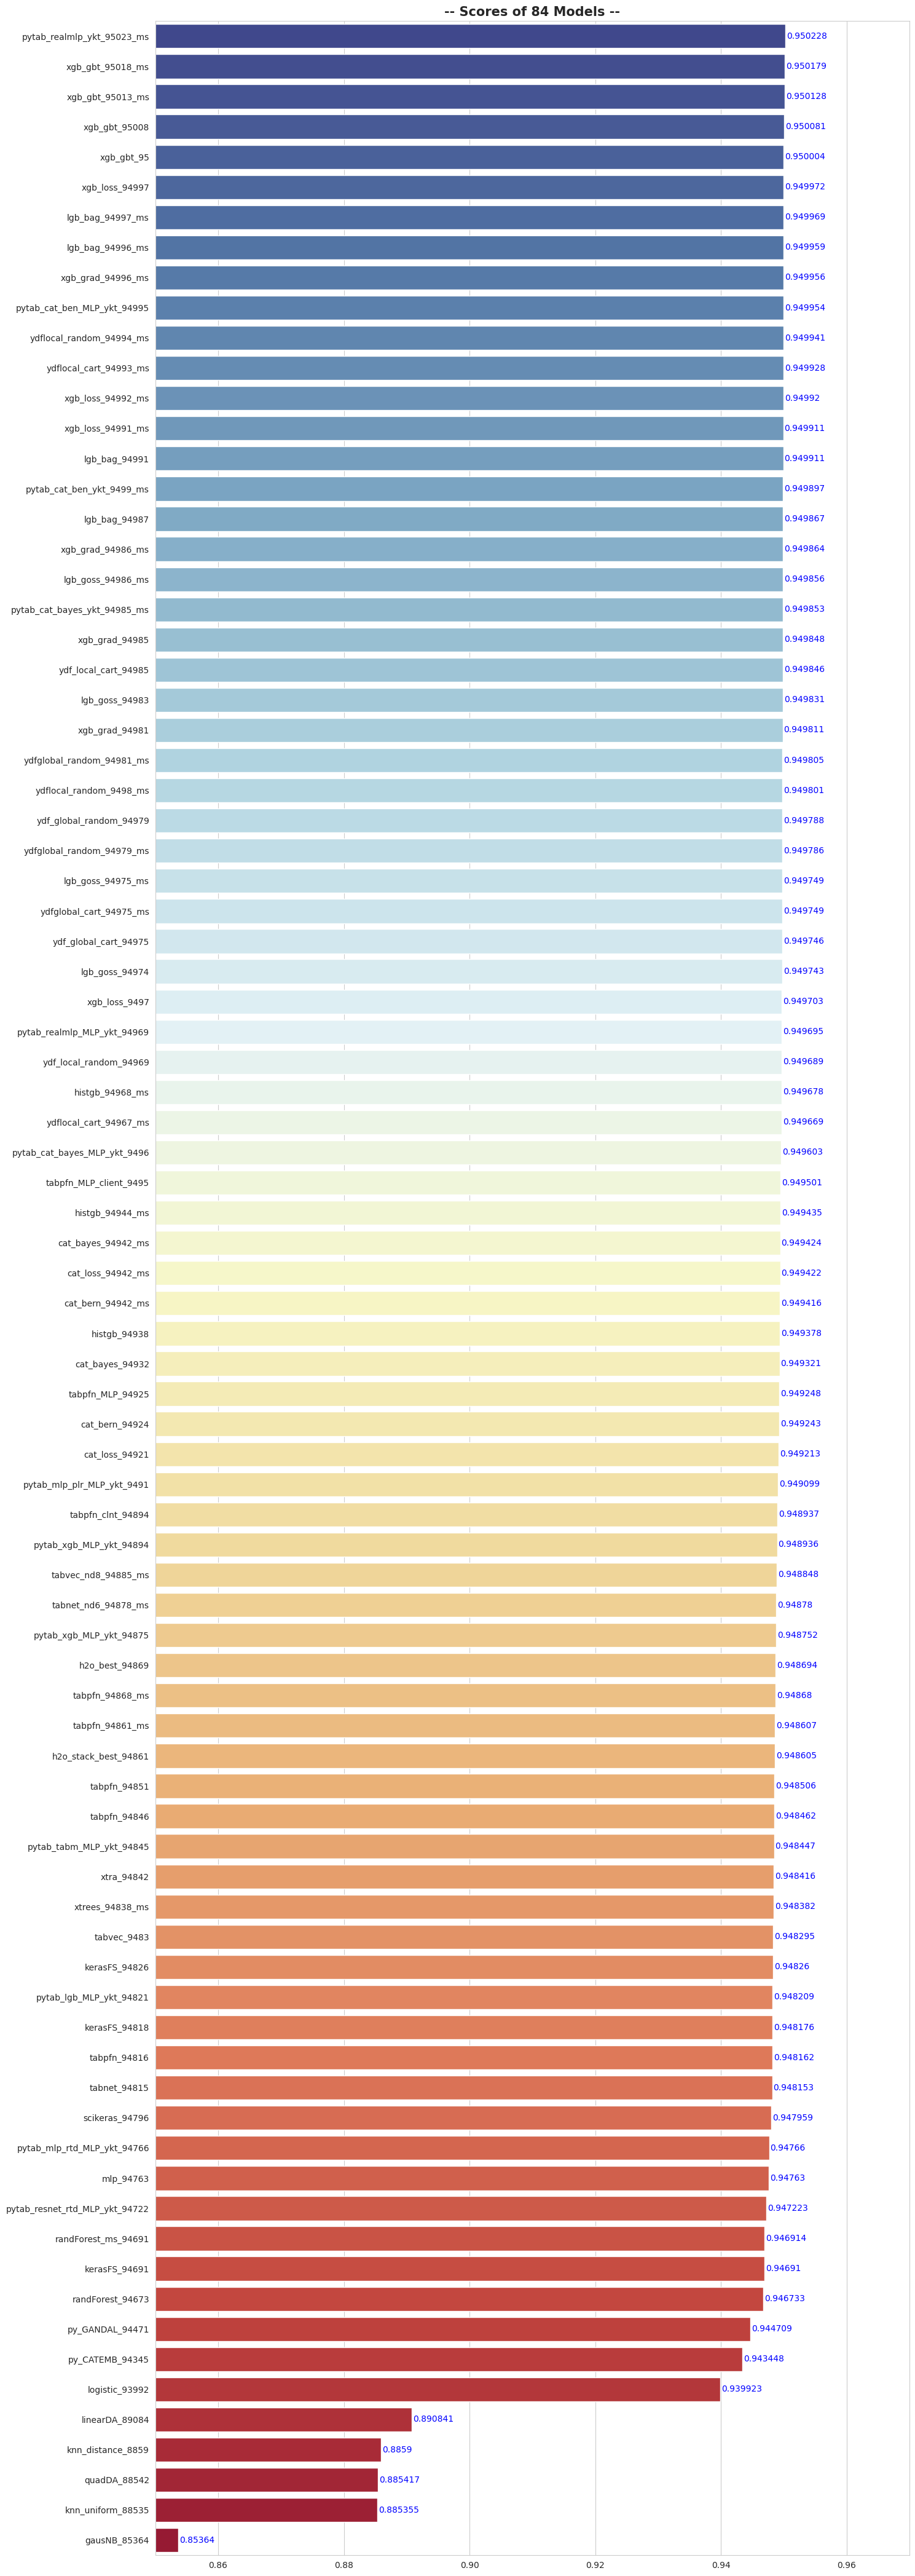

In [16]:
def get_model_scores(oof_predictions_dict, y_true):
    """
    Computes balanced accuracy for each model in the dictionary.
    """
    scores = {}
    for model_name, preds in oof_predictions_dict.items():
        bal_acc = balanced_acc(y_true, preds)
        scores[model_name] = np.round(bal_acc, 6)
        # print(f"{model_name:>30}: {bal_acc:.6f}")

    return scores

## -- Calculate validation scores for each model
model_scores = get_model_scores(oof_dict, y_true)
model_scores_df = pd.Series(model_scores).sort_values(ascending=False)

## -- Plot model scores --
plt.figure(figsize=(15, len(model_scores) * 0.5))
sns.barplot(model_scores_df, orient='h', palette='RdYlBu_r', native_scale=True)

for i, score in enumerate(model_scores_df.values):
    plt.text(score+2e-4, model_scores_df.index[i], score, ha='left', va='center', color='b')

plt.title(f"-- Scores of {len(model_scores_df)} Models --", fontsize=15, fontweight='semibold')
plt.xlim(0.85, 0.97)
plt.tight_layout()
plt.show()

In [17]:
# # %%writefile check_func.py
# # import numpy as np
# # import pandas as pd

# from scipy.spatial.distance import jensenshannon

# def check_model_redundancy(oof_predictions_dict, threshold=0.98):
#     """
#     Checks for redundancy among base models using multi-class probabilities.
#     oof_predictions_dict: dict of {model_name: 2D numpy array of shape (N_samples, 3_classes)}
#     threshold: Correlation/Similarity index above which a model is considered redundant
#     """
#     model_names = list(oof_predictions_dict.keys())
#     n_models = len(model_names)
    
#     # Initialize a similarity matrix
#     similarity_matrix = np.zeros((n_models, n_models))
    
#     for i in range(n_models):
#         for j in range(n_models):
#             # Compute average Jensen-Shannon distance row-wise and invert for similarity
#             js_distances = [jensenshannon(oof_predictions_dict[model_names[i]][k], 
#                                          oof_predictions_dict[model_names[j]][k], base=2.0) 
#                             for k in range(len(oof_predictions_dict[model_names[i]]))]
            
#             # Convert distance to similarity score [0, 1]
#             similarity_matrix[i, j] = 1 - np.mean(js_distances)
            
#     similarity_df = pd.DataFrame(similarity_matrix, index=model_names, columns=model_names)
    
#     # Identify pairs exceeding threshold 
#     redundant_pairs = []
#     for i in range(n_models):
#         for j in range(i + 1, n_models):
#             if similarity_df.iloc[i, j] > threshold:
#                 redundant_pairs.append((model_names[i], model_names[j], similarity_df.iloc[i, j]))
                
#     return similarity_df, redundant_pairs 

# print("Redundancy check function ready!")

In [18]:
# from check_func import check_model_redundancy 
# %lprun -f check_model_redundancy check_model_redundancy(oof_dict, threshold=0.98)
# %mprun -f check_model_redundancy check_model_redundancy(oof_dict, threshold=0.98)

In [19]:
# %%time

# similarity_df, redundant_pairs = check_model_redundancy(oof_dict, threshold=0.98)
# # display(similarity_df)

# plt.figure(figsize=(16, 6))
# sns.heatmap(similarity_df, annot=True, center=0)
# plt.show()

In [20]:
from scipy.spatial.distance import jensenshannon

def check_model_redundancy(oof_predictions_dict, threshold=0.98):
    """
    Checks for redundancy among base models using multi-class probabilities.
    oof_predictions_dict: dict of {model_name: 2D numpy array of shape (N_samples, 3_classes)}
    threshold: Correlation/Similarity index above which a model is considered redundant
    """
    model_names = list(oof_predictions_dict.keys())
    n_models = len(model_names)
    
    similarity_matrix = np.eye(n_models)
    
    # 1. Compute similarity matrix efficiently
    for i in range(n_models):
        for j in range(i + 1, n_models):
            js_distances = jensenshannon(
                oof_predictions_dict[model_names[i]], 
                oof_predictions_dict[model_names[j]], 
                base=2.0, axis=1
            )
            similarity = 1.0 - np.nanmean(js_distances)
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity
            
    similarity_df = pd.DataFrame(similarity_matrix, index=model_names, columns=model_names)
    
    # 2. Identify and rank redundant pairs
    redundant_pairs = []
    for i in range(n_models):
        for j in range(i + 1, n_models):
            if similarity_matrix[i, j] > threshold:
                redundant_pairs.append((model_names[i], model_names[j], similarity_matrix[i, j]))
    
    # Sort pairs by highest similarity first to deal with the most redundant models first
    redundant_pairs.sort(key=lambda x: x[2], reverse=True)

    return similarity_df, redundant_pairs 

print("Redundancy check function ready!")

Redundancy check function ready!


In [21]:
%%time

similarity_df, redundant_pairs = check_model_redundancy(oof_dict, threshold=0.98)
display(similarity_df)

# plt.figure(figsize=(16, 6))
# sns.heatmap(similarity_df, annot=True, center=0)
# plt.show()

,tabpfn_clnt_94894,quadDA_88542,logistic_93992,ydfglobal_random_94981_ms,cat_bern_94924,ydfglobal_cart_94975_ms,tabpfn_94851,xgb_loss_94992_ms,cat_bern_94942_ms,pytab_cat_ben_ykt_9499_ms,ydf_local_random_94969,ydf_local_cart_94985,ydflocal_random_9498_ms,tabpfn_94861_ms,lgb_bag_94991,linearDA_89084,cat_bayes_94942_ms,kerasFS_94691,lgb_bag_94997_ms,lgb_goss_94986_ms,knn_distance_8859,knn_uniform_88535,pytab_xgb_MLP_ykt_94894,tabvec_9483,cat_bayes_94932,xtra_94842,ydfglobal_random_94979_ms,xgb_gbt_95,gausNB_85364,py_CATEMB_94345,xgb_gbt_95008,lgb_bag_94996_ms,h2o_best_94869,tabpfn_94846,py_GANDAL_94471,tabpfn_MLP_client_9495,mlp_94763,pytab_mlp_plr_MLP_ykt_9491,kerasFS_94818,xgb_grad_94986_ms,pytab_realmlp_ykt_95023_ms,tabpfn_94868_ms,ydflocal_cart_94993_ms,histgb_94944_ms,tabnet_94815,ydflocal_random_94994_ms,tabnet_nd6_94878_ms,cat_loss_94921,randForest_94673,ydf_global_random_94979,lgb_goss_94974,pytab_tabm_MLP_ykt_94845,cat_loss_94942_ms,pytab_lgb_MLP_ykt_94821,xtrees_94838_ms,xgb_loss_94997,xgb_grad_94981,pytab_resnet_rtd_MLP_ykt_94722,xgb_grad_94985,xgb_loss_9497,xgb_gbt_95013_ms,kerasFS_94826,pytab_cat_bayes_ykt_94985_ms,lgb_goss_94983,pytab_realmlp_MLP_ykt_94969,xgb_grad_94996_ms,histgb_94968_ms,pytab_cat_ben_MLP_ykt_94995,pytab_cat_bayes_MLP_ykt_9496,lgb_bag_94987,ydflocal_cart_94967_ms,ydf_global_cart_94975,tabvec_nd8_94885_ms,xgb_gbt_95018_ms,h2o_stack_best_94861,tabpfn_MLP_94925,pytab_mlp_rtd_MLP_ykt_94766,pytab_xgb_MLP_ykt_94875,lgb_goss_94975_ms,histgb_94938,xgb_loss_94991_ms,tabpfn_94816,randForest_ms_94691,scikeras_94796
tabpfn_clnt_94894,1.000000,0.789963,0.830433,0.947708,0.948037,0.947000,0.964344,0.945790,0.949679,0.935715,0.945033,0.945136,0.946296,0.971406,0.947720,0.801312,0.944222,0.916400,0.949717,0.943566,0.783877,0.781808,0.920285,0.943539,0.942029,0.937997,0.947239,0.941822,0.743803,0.926098,0.940607,0.942722,0.934470,0.965933,0.933823,0.966517,0.925346,0.926491,0.941460,0.941100,0.899517,0.972593,0.945222,0.937836,0.938611,0.945600,0.946955,0.948229,0.869096,0.947389,0.941921,0.938372,0.949737,0.924811,0.945340,0.944855,0.941378,0.915903,0.940694,0.944930,0.941462,0.940909,0.933785,0.936613,0.872720,0.941126,0.949590,0.936521,0.931638,0.938021,0.946078,0.946603,0.945463,0.942835,0.930337,0.961654,0.886896,0.922511,0.944754,0.940764,0.945074,0.977281,0.891193,0.938123
quadDA_88542,0.789963,1.000000,0.758650,0.807423,0.806221,0.807695,0.795894,0.803023,0.807542,0.817295,0.805263,0.804267,0.807414,0.793212,0.791170,0.784883,0.807532,0.764060,0.792636,0.799483,0.787900,0.786741,0.813197,0.808148,0.805480,0.780546,0.805728,0.796071,0.778548,0.799474,0.797346,0.804792,0.794341,0.793069,0.808107,0.792970,0.794099,0.795293,0.811001,0.802503,0.822955,0.795531,0.805086,0.821775,0.812076,0.805321,0.817083,0.807949,0.784751,0.806281,0.797912,0.825609,0.809013,0.808639,0.783874,0.804391,0.796836,0.793064,0.801606,0.804678,0.798162,0.803299,0.819693,0.814265,0.817621,0.798998,0.788010,0.818100,0.821714,0.812019,0.806826,0.805523,0.817361,0.797206,0.787744,0.785612,0.792568,0.796010,0.793578,0.816938,0.805002,0.795041,0.804038,0.796351
logistic_93992,0.830433,0.758650,1.000000,0.825951,0.827464,0.825678,0.831484,0.830149,0.827620,0.826936,0.825596,0.825382,0.825148,0.834113,0.834890,0.820076,0.828546,0.821984,0.834759,0.834112,0.758092,0.757096,0.824373,0.816994,0.828481,0.822412,0.826208,0.836032,0.738236,0.816126,0.833721,0.835511,0.820314,0.833105,0.814157,0.832238,0.819108,0.819292,0.817665,0.833468,0.799452,0.833086,0.825566,0.816934,0.820928,0.825674,0.819365,0.827552,0.823800,0.826202,0.834144,0.817041,0.827702,0.823057,0.823205,0.828795,0.834726,0.813409,0.833249,0.830424,0.833889,0.817823,0.829620,0.837080,0.785756,0.833872,0.826252,0.827715,0.829391,0.836765,0.825092,0.825692,0.817670,0.836342,0.821365,0.835334,0.798424,0.830551,0.833926,0.818452,0.829645,0.832886,0.826697,0.820105
ydfglobal_random_94981_ms,0.947708,0.807423,0.825951,1.000000,0.969460,0.990458,0.939477,0.968902,0.972198,0.949555,0.976500,

CPU times: user 7min 59s, sys: 28.9 s, total: 8min 28s
Wall time: 8min 28s


In [22]:
redundant_pairs

[('ydf_local_cart_94985',
  'ydflocal_cart_94993_ms',
  np.float64(0.9948179755120499)),
 ('tabpfn_94861_ms', 'tabpfn_94868_ms', np.float64(0.992669725048006)),
 ('ydflocal_random_9498_ms',
  'ydflocal_cart_94967_ms',
  np.float64(0.9918762958941374)),
 ('ydfglobal_random_94981_ms',
  'ydfglobal_cart_94975_ms',
  np.float64(0.9904583937258801)),
 ('ydflocal_cart_94993_ms',
  'ydflocal_random_94994_ms',
  np.float64(0.9903406059949929)),
 ('xgb_loss_94992_ms', 'xgb_loss_94991_ms', np.float64(0.9897771646717891)),
 ('ydfglobal_random_94981_ms',
  'ydf_global_random_94979',
  np.float64(0.9895930624492366)),
 ('ydfglobal_random_94979_ms',
  'ydf_global_cart_94975',
  np.float64(0.9893432956381591)),
 ('ydf_local_random_94969',
  'ydflocal_random_94994_ms',
  np.float64(0.9889926239569877)),
 ('cat_bern_94942_ms', 'cat_loss_94942_ms', np.float64(0.9889342550381107)),
 ('tabpfn_94851', 'tabpfn_94846', np.float64(0.9882733076795842)),
 ('xgb_grad_94986_ms', 'xgb_grad_94985', np.float64(0.988

In [23]:
def select_usable_models(oof_predictions_dict, redundant_pairs, model_scores):
    """
    Returns a sorted list of unique models after dropping lower-performing 
    redundant models.
    """
    all_models = set(oof_predictions_dict.keys())
    models_to_drop = set()

    for model_a, model_b, similarity in redundant_pairs:
        score_a = model_scores[model_a]
        score_b = model_scores[model_b]

        # Identify the weaker model and mark it for dropping
        if score_a >= score_b:
            models_to_drop.add(model_b)
            print(f"Dropping {model_b} (Score: {score_b:.6f}) in favor of {model_a} (Score: {score_a:.6f})")
        else:
            models_to_drop.add(model_a)
            print(f"Dropping {model_a} (Score: {score_a:.6f}) in favor of {model_b} (Score: {score_b:.6f})")

    # Keep only non-redundant models
    usable_models = list(all_models - models_to_drop)

    return usable_models

print("Usable models function ready!") 

Usable models function ready!


In [24]:
usable_model_names = select_usable_models(oof_dict, redundant_pairs, model_scores)

# 3. Expand model names back into full column names (_c0, _c1, _c2) for slicing DataFrames
usable_columns = []

for model_name in usable_model_names:
    usable_columns.append([f"{model_name}__c0", f"{model_name}__c1", f"{model_name}__c2"])

print(f"\n✓ Retained {len(usable_columns)} / {len(oof_dict)} models.")

Dropping ydf_local_cart_94985 (Score: 0.949846) in favor of ydflocal_cart_94993_ms (Score: 0.949928)
Dropping tabpfn_94861_ms (Score: 0.948607) in favor of tabpfn_94868_ms (Score: 0.948680)
Dropping ydflocal_cart_94967_ms (Score: 0.949669) in favor of ydflocal_random_9498_ms (Score: 0.949801)
Dropping ydfglobal_cart_94975_ms (Score: 0.949749) in favor of ydfglobal_random_94981_ms (Score: 0.949805)
Dropping ydflocal_cart_94993_ms (Score: 0.949928) in favor of ydflocal_random_94994_ms (Score: 0.949941)
Dropping xgb_loss_94991_ms (Score: 0.949911) in favor of xgb_loss_94992_ms (Score: 0.949920)
Dropping ydf_global_random_94979 (Score: 0.949788) in favor of ydfglobal_random_94981_ms (Score: 0.949805)
Dropping ydf_global_cart_94975 (Score: 0.949746) in favor of ydfglobal_random_94979_ms (Score: 0.949786)
Dropping ydf_local_random_94969 (Score: 0.949689) in favor of ydflocal_random_94994_ms (Score: 0.949941)
Dropping cat_bern_94942_ms (Score: 0.949416) in favor of cat_loss_94942_ms (Score: 0

In [25]:
usable_columns_ext = sum(usable_columns, [])
usable_columns_ext

['knn_distance_8859__c0',
 'knn_distance_8859__c1',
 'knn_distance_8859__c2',
 'cat_loss_94942_ms__c0',
 'cat_loss_94942_ms__c1',
 'cat_loss_94942_ms__c2',
 'histgb_94938__c0',
 'histgb_94938__c1',
 'histgb_94938__c2',
 'py_GANDAL_94471__c0',
 'py_GANDAL_94471__c1',
 'py_GANDAL_94471__c2',
 'xtrees_94838_ms__c0',
 'xtrees_94838_ms__c1',
 'xtrees_94838_ms__c2',
 'pytab_cat_ben_MLP_ykt_94995__c0',
 'pytab_cat_ben_MLP_ykt_94995__c1',
 'pytab_cat_ben_MLP_ykt_94995__c2',
 'lgb_bag_94987__c0',
 'lgb_bag_94987__c1',
 'lgb_bag_94987__c2',
 'quadDA_88542__c0',
 'quadDA_88542__c1',
 'quadDA_88542__c2',
 'pytab_mlp_rtd_MLP_ykt_94766__c0',
 'pytab_mlp_rtd_MLP_ykt_94766__c1',
 'pytab_mlp_rtd_MLP_ykt_94766__c2',
 'ydfglobal_random_94981_ms__c0',
 'ydfglobal_random_94981_ms__c1',
 'ydfglobal_random_94981_ms__c2',
 'pytab_lgb_MLP_ykt_94821__c0',
 'pytab_lgb_MLP_ykt_94821__c1',
 'pytab_lgb_MLP_ykt_94821__c2',
 'tabvec_nd8_94885_ms__c0',
 'tabvec_nd8_94885_ms__c1',
 'tabvec_nd8_94885_ms__c2',
 'kerasFS_

In [26]:
oof_df  = oof_df[usable_columns_ext]
test_df = test_df[usable_columns_ext]

oof_df

,knn_distance_8859__c0,knn_distance_8859__c1,knn_distance_8859__c2,cat_loss_94942_ms__c0,cat_loss_94942_ms__c1,cat_loss_94942_ms__c2,histgb_94938__c0,histgb_94938__c1,histgb_94938__c2,py_GANDAL_94471__c0,py_GANDAL_94471__c1,py_GANDAL_94471__c2,xtrees_94838_ms__c0,xtrees_94838_ms__c1,xtrees_94838_ms__c2,pytab_cat_ben_MLP_ykt_94995__c0,pytab_cat_ben_MLP_ykt_94995__c1,pytab_cat_ben_MLP_ykt_94995__c2,lgb_bag_94987__c0,lgb_bag_94987__c1,lgb_bag_94987__c2,quadDA_88542__c0,quadDA_88542__c1,quadDA_88542__c2,pytab_mlp_rtd_MLP_ykt_94766__c0,pytab_mlp_rtd_MLP_ykt_94766__c1,pytab_mlp_rtd_MLP_ykt_94766__c2,ydfglobal_random_94981_ms__c0,ydfglobal_random_94981_ms__c1,ydfglobal_random_94981_ms__c2,pytab_lgb_MLP_ykt_94821__c0,pytab_lgb_MLP_ykt_94821__c1,pytab_lgb_MLP_ykt_94821__c2,tabvec_nd8_94885_ms__c0,tabvec_nd8_94885_ms__c1,tabvec_nd8_94885_ms__c2,kerasFS_94818__c0,kerasFS_94818__c1,kerasFS_94818__c2,cat_bayes_94942_ms__c0,cat_bayes_94942_ms__c1,cat_bayes_94942_ms__c2,pytab_realmlp_ykt_95023_ms__c0,pytab_realmlp_ykt_95023_ms__c1,pytab_realmlp_ykt_95023_ms__c2,py_CATEMB_94345__c0,py_CATEMB_94345__c1,py_CATEMB_94345__c2,randForest_ms_94691__c0,randForest_ms_94691__c1,randForest_ms_94691__c2,kerasFS_94691__c0,kerasFS_94691__c1,kerasFS_94691__c2,mlp_94763__c0,mlp_94763__c1,mlp_94763__c2,tabnet_94815__c0,tabnet_94815__c1,tabnet_94815__c2,pytab_resnet_rtd_MLP_ykt_94722__c0,pytab_resnet_rtd_MLP_ykt_94722__c1,pytab_resnet_rtd_MLP_ykt_94722__c2,tabpfn_MLP_client_9495__c0,tabpfn_MLP_client_9495__c1,tabpfn_MLP_client_9495__c2,tabpfn_MLP_94925__c0,tabpfn_MLP_94925__c1,tabpfn_MLP_94925__c2,pytab_mlp_plr_MLP_ykt_9491__c0,pytab_mlp_plr_MLP_ykt_9491__c1,pytab_mlp_plr_MLP_ykt_9491__c2,h2o_best_94869__c0,h2o_best_94869__c1,h2o_best_94869__c2,scikeras_94796__c0,scikeras_94796__c1,scikeras_94796__c2,tabnet_nd6_94878_ms__c0,tabnet_nd6_94878_ms__c1,tabnet_nd6_94878_ms__c2,pytab_realmlp_MLP_ykt_94969__c0,pytab_realmlp_MLP_ykt_94969__c1,pytab_realmlp_MLP_ykt_94969__c2,histgb_94968_ms__c0,histgb_94968_ms__c1,histgb_94968_ms__c2,h2o_stack_best_94861__c0,h2o_stack_best_94861__c1,h2o_stack_best_94861__c2,lgb_bag_94996_ms__c0,lgb_bag_94996_ms__c1,lgb_bag_94996_ms__c2,xgb_gbt_95018_ms__c0,xgb_gbt_95018_ms__c1,xgb_gbt_95018_ms__c2,gausNB_85364__c0,gausNB_85364__c1,gausNB_85364__c2,logistic_93992__c0,logistic_93992__c1,logistic_93992__c2,tabpfn_clnt_94894__c0,tabpfn_clnt_94894__c1,tabpfn_clnt_94894__c2,randForest_94673__c0,randForest_94673__c1,randForest_94673__c2,pytab_xgb_MLP_ykt_94875__c0,pytab_xgb_MLP_ykt_94875__c1,pytab_xgb_MLP_ykt_94875__c2,tabpfn_94868_ms__c0,tabpfn_94868_ms__c1,tabpfn_94868_ms__c2,ydflocal_random_94994_ms__c0,ydflocal_random_94994_ms__c1,ydflocal_random_94994_ms__c2,histgb_94944_ms__c0,histgb_94944_ms__c1,histgb_94944_ms__c2,pytab_tabm_MLP_ykt_94845__c0,pytab_tabm_MLP_ykt_94845__c1,pytab_tabm_MLP_ykt_94845__c2,pytab_xgb_MLP_ykt_94894__c0,pytab_xgb_MLP_ykt_94894__c1,pytab_xgb_MLP_ykt_94894__c2,tabvec_9483__c0,tabvec_9483__c1,tabvec_9483__c2,xgb_loss_94997__c0,xgb_loss_94997__c1,xgb_loss_94997__c2,kerasFS_94826__c0,kerasFS_94826__c1,kerasFS_94826__c2,xtra_94842__c0,xtra_94842__c1,xtra_94842__c2,linearDA_89084__c0,linearDA_89084__c1,linearDA_89084__c2,lgb_goss_94986_ms__c0,lgb_goss_94986_ms__c1,lgb_goss_94986_ms__c2,lgb_bag_94997_ms__c0,lgb_bag_94997_ms__c1,lgb_bag_94997_ms__c2,tabpfn_94816__c0,tabpfn_94816__c1,tabpfn_94816__c2
0,0.007349,0.002309,0.990342,0.001269,0.001928,0.996803,0.002540,0.002184,0.995276,0.000545,0.000092,0.999363,0.000749,0.000080,0.999171,0.002159,0.000334,0.997508,0.001096,0.003349,0.995555,0.004555,0.040711,0.954734,0.000012,2.049986e-07,0.999988,0.002051,0.002003,0.995946,0.006652,0.002229,0.991119,0.001168,0.000207,0.998625,0.001033,0.000073,0.998894,0.001373,0.001995,0.996632,0.007990,0.000659,0.991352,0.000456,0.000120,0.999424,0.001170,0.000628,0.998202,0.000081,0.000148,0.999771,1.218078e-03,0.000043,9.987393e-01,0.000387,0.000546,0.999067,0.002200,0.000063,0.997737,0.001594,0.000189,0.998217,0.002160,0.000207,0.99763

In [27]:
# for m in per_model_output:
#     # print(m)
#     # display(oof_df[m][:3])
#     oof_df.loc[:, m] = robust_logit(oof_df[m])

# c0 = [c for c in oof_df.columns if "_c0" in c]
# c1 = [c for c in oof_df.columns if "_c1" in c]
# c2 = [c for c in oof_df.columns if "_c2" in c]

# plt.figure(figsize=(18, 15))
# sns.heatmap(oof_df[c0].corr("spearman"), annot=True)
# plt.tight_layout()
# plt.show()

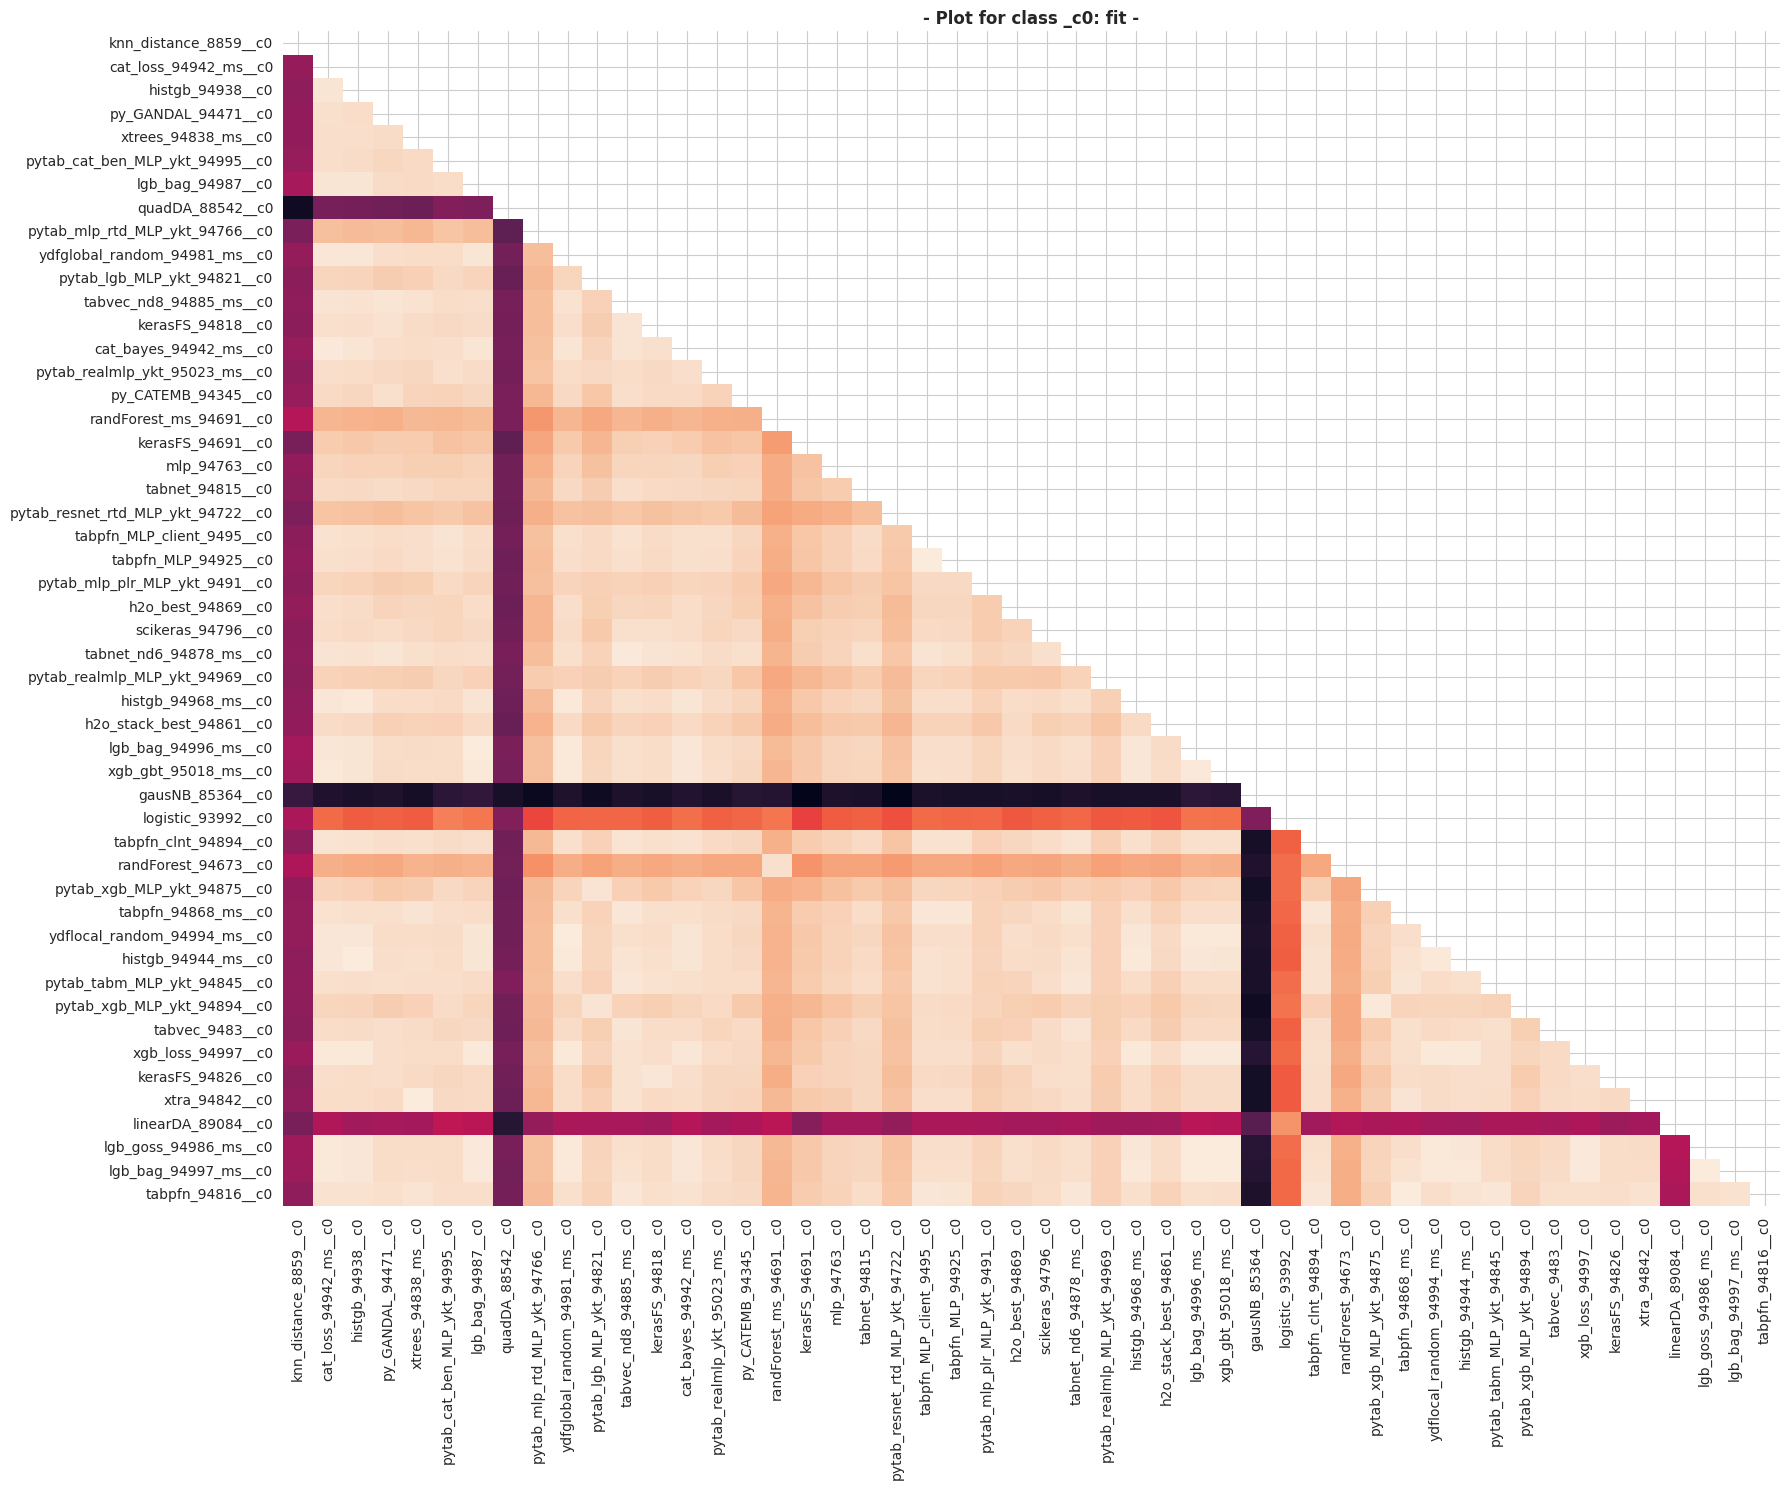

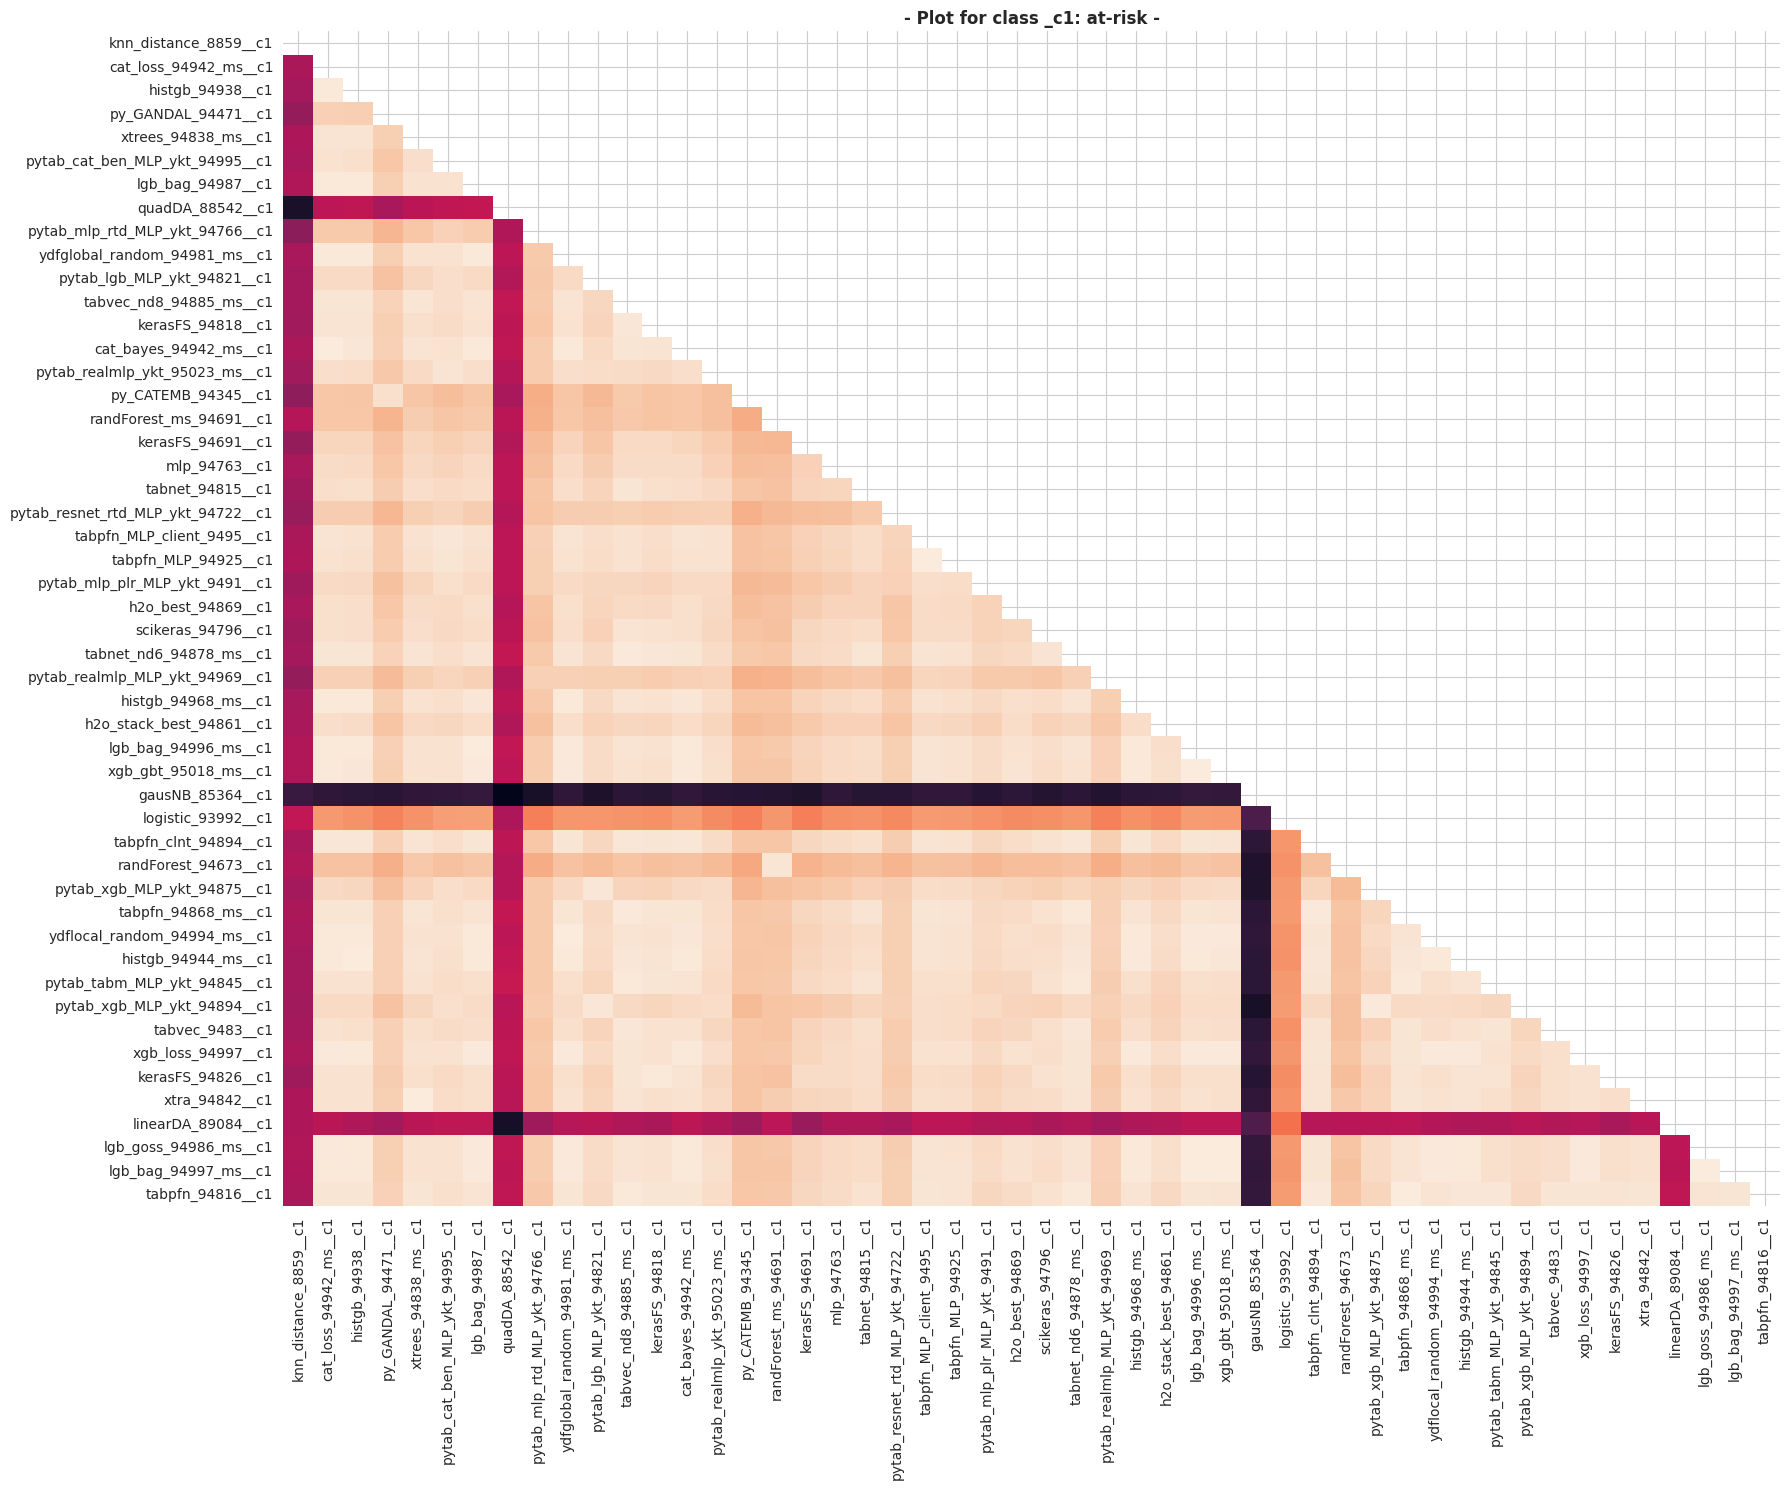

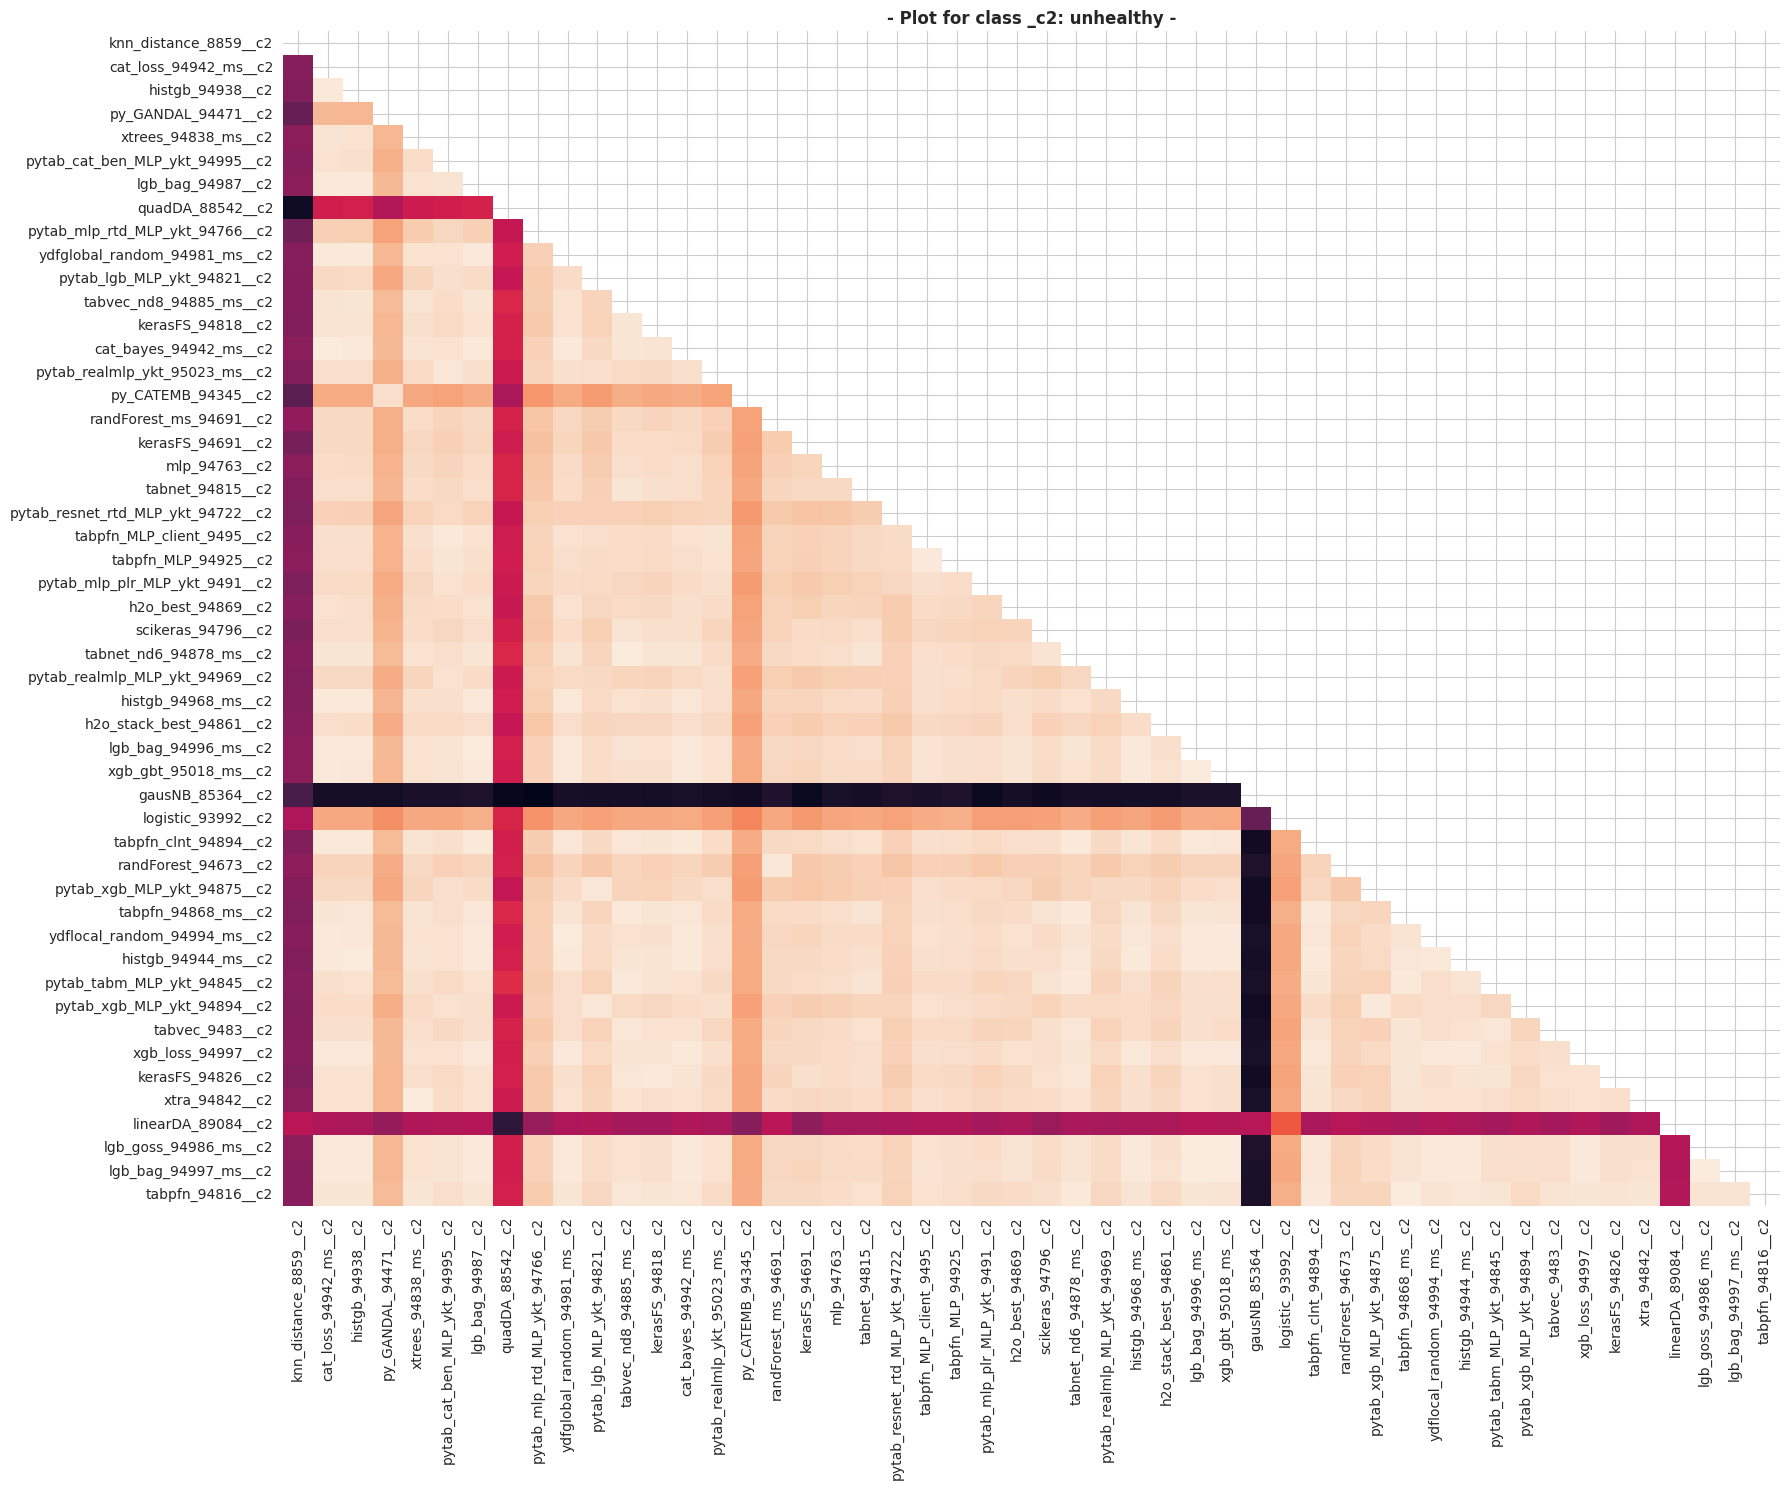

In [28]:
## -- Correlation Analysis --
classes_ = ["_c0", "_c1", "_c2"]

for i, class_ in enumerate(classes_):
    cls_ = [c for c in oof_df.columns if c.endswith(class_)]
    corr_df = oof_df[cls_].corr()

    plt.figure(figsize=(18, 15))
    sns.heatmap(corr_df, mask=np.triu(corr_df), fmt=".3f", cbar=False)
    plt.title(f"- Plot for class {class_}: {r_mapping[i]} -", fontweight="semibold")
    plt.tight_layout()
    plt.show()
    print()

## GROUP LASSO SELECTION

In [29]:
# %%time

# try:
#     from group_lasso import LogisticGroupLasso
# except:
#     %pip install -q -U group-lasso
#     from group_lasso import LogisticGroupLasso

# groups = np.concatenate([len(m) * [i] for i, m in enumerate(per_model_output)])
# print("Model groups: \n", groups)

# gl = LogisticGroupLasso(
#     groups=groups,
#     # group_reg=0.05,
#     # l1_reg=0,
#     # tol=1e-4,
#     scale_reg=None,
#     # subsampling_scheme=0.8,
#     supress_warning=True,
#     random_state=CFG['SEED'],
# )

# gl.fit_predict(x_tr, y_tr) # fit->labels | fit_predict->probas

In [30]:
# x_transformed = gl.fit_transform(x_tr, y_tr)
# x_transformed

In [31]:
# ## Extract info from estimator
# gl_proba = gl.predict_proba(x_ts)
# sparsity_mask = gl.sparsity_mask_

# ## Compute performance metrics
# bal_acc = balanced_acc(y_ts, gl_proba)

# ## Print results
# print(f"Accuracy: {bal_acc}") #, best possible accuracy = {best_accuracy}")
# print(f"Number variables: {len(sparsity_mask)}")
# print(f"Number of chosen variables: {sparsity_mask.sum()}")
# print(f"Chosen groups \n", gl.chosen_groups_)

# gl_models = [per_model_output[i] for i in gl.chosen_groups_]
# gl_models

In [32]:
# fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# ax[0].plot(gl.coef_); ax[0].set_xlabel("Number of models")
# ax[1].plot(gl.losses_)
# plt.show()

## PYGLMNET SELECTION

In [33]:
# try:
#     from pyglmnet import GLM, GLMCV
# except:
#     %pip install -q -U pyglmnet
#     from pyglmnet import GLM, GLMCV

# groups = np.concatenate([len(m) * [i+1] for i, m in enumerate(per_model_output)])
# print("Model groups: \n", groups)

# # set up the group lasso GLM model
# gl_glm = GLMCV(
#     distr="binomial",
#     score_metric="pseudo_R2",
#     group=groups,
#     tol=1e-5,
#     # alpha=1.0,
#     # learning_rate=0.2,
#     max_iter=100,
#     cv=5,
#     verbose=True,
# )


# # set up the lasso model
# glm = GLMCV(
#     distr="binomial",
#     score_metric="pseudo_R2",
#     tol=1e-5,
#     # alpha=1.0,
#     # learning_rate=0.2,
#     max_iter=100,
#     cv=5,
#     verbose=True,
# )

# print("gl_glm: ", gl_glm)
# print("glm: ", glm)

In [34]:
# gl_glm.fit(x_tr.to_numpy(), y_tr.to_numpy())
# glm.fit(x_tr.to_numpy(), y_tr.to_numpy())

In [35]:
# def objective(trial):
#     skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG["SEED"])
    
#     # C = trial.suggest_float("C", 1e-5, 1e2, log=True)
#     # TOL = trial.suggest_float("tol", 1e-5, 1e-3)
#     C = trial.suggest_categorical("C", [1e-3, 1e-2, 1e-1, 1e0, 1e1])
#     TOL = trial.suggest_categorical("tol", [1e-5, 1e-4, 1e-3])

#     model = LogisticRegression(
#         C=C, tol=TOL, max_iter=1000, # n_jobs=2,
#         class_weight="balanced", random_state=CFG['SEED'],
#     )

#     scores = cross_val_score(model, oof_df, y_true, cv=skf, scoring=METRIC)
#     return scores.mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30, show_progress_bar=True) # , n_jobs=-1

# print('='*50)
# print(f"{CFG["YELLOW"]}Best C:   {study.best_params['C']}")
# print(f"Best tol: {study.best_params['tol']}")
# print(f"Best CV Accuracy: {study.best_value:.5f}{CFG["RESET"]}")

In [36]:
%%time

def objective(trial):
    skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG["SEED"])

    # C = trial.suggest_float("C", 1e-5, 1e2, log=True)
    # TOL = trial.suggest_float("tol", 1e-5, 1e-3)
    C = trial.suggest_categorical("C", [1e-3, 1e-2, 1e-1, 1e0])
    TOL = trial.suggest_categorical("tol", [1e-5, 1e-4])

    model = LogisticRegression(
        C=C,
        tol=TOL,
        max_iter=5000,
        class_weight="balanced",
        random_state=CFG['SEED'],
        n_jobs=-1, 
    )

    model = make_pipeline(StandardScaler(), model)

    X = scipy_logit(oof_df)
    # print(f"X shape = {X.shape}")

    scores = cross_val_score(model, X, y_true, cv=skf, scoring=METRIC)
    return np.round(scores.mean(), 6)

# ## -- Option A: Create a study injected with the GridSampler
# search_space = {"C": [1e-3, 1e-2, 1e-1], "tol": [1e-5, 1e-4]}
# study = optuna.create_study(sampler=optuna.samplers.GridSampler(search_space), direction="maximize")

## -- Option B: Dynamically search all variants with BruteForceSampler
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.BruteForceSampler()
)

study.optimize(objective, show_progress_bar=True)

print(f"{CFG["YELLOW"]}{'='*55}") 
print(f"Best C:     {study.best_params['C']}")
print(f"Best tol:   {study.best_params['tol']}")
print(f"Best score: {study.best_value:.6f}")
print(f"{'='*55}{CFG["RESET"]}")

[I 2026-08-06 00:45:17,456] A new study created in memory with name: no-name-11ca14f3-5170-446c-87fe-f3d61f625c5a
[I 2026-08-06 00:49:49,414] Trial 0 finished with value: 0.950636 and parameters: {'C': 0.001, 'tol': 1e-05}. Best is trial 0 with value: 0.950636.
[I 2026-08-06 00:59:16,390] Trial 1 finished with value: 0.950504 and parameters: {'C': 0.01, 'tol': 1e-05}. Best is trial 0 with value: 0.950636.
[I 2026-08-06 01:04:03,585] Trial 2 finished with value: 0.950461 and parameters: {'C': 0.01, 'tol': 0.0001}. Best is trial 0 with value: 0.950636.
[I 2026-08-06 01:36:51,295] Trial 3 finished with value: 0.95028 and parameters: {'C': 1.0, 'tol': 1e-05}. Best is trial 0 with value: 0.950636.
[I 2026-08-06 01:45:44,937] Trial 4 finished with value: 0.950253 and parameters: {'C': 1.0, 'tol': 0.0001}. Best is trial 0 with value: 0.950636.
[I 2026-08-06 01:48:42,163] Trial 5 finished with value: 0.95066 and parameters: {'C': 0.001, 'tol': 0.0001}. Best is trial 5 with value: 0.95066.
[I 2

Best C:     0.001
Best tol:   0.0001
Best score: 0.950660
CPU times: user 2min 5s, sys: 43.3 s, total: 2min 49s
Wall time: 1h 31min 10s


In [37]:
# =======================================================
# Best C:     0.001
# Best tol:   0.0001
# Best score: 0.950662
# =======================================================
# CPU times: user 1min 14s, sys: 32.6 s, total: 1min 47s
# Wall time: 1h 7min 6s

In [38]:
optuna.visualization.plot_param_importances(study)

In [39]:
optuna.visualization.plot_optimization_history(study)

In [40]:
# %%time

# l_model = LogisticRegression(**{
#     'C':            study.best_params['C'],
#     'tol':          study.best_params['tol'],
#     'max_iter':     5000,
#     'class_weight': "balanced",
#     'random_state': CFG["SEED"],
#     'n_jobs':       64 if os.cpu_count() > 4 else 3,
# })


# N_ROUNDS = 10
# skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG["SEED"])
# pipe_model =  make_pipeline(FunctionTransformer(scipy_logit), StandardScaler(), l_model)

# print(f"Computing {N_ROUNDS} rounds permutation scores...", end='')
# score, permutation_scores, pvalue = permutation_test_score(
#     pipe_model,
#     oof_df,
#     y_true,
#     cv=skf,
#     scoring=METRIC, 
#     n_permutations=N_ROUNDS,
#     random_state=CFG["SEED"],
#     n_jobs=-1,
#     verbose=1,
# )

# ## -- Extract CV scores and p-value by testing permutations of labels
# ## -- 1. Large p-value (0.1+): Variables are not predictive of class labels
# ## -- 2. Lower p-value (~0.1): Variables are strong predictive of class labels

# print(f"Complete") 
# print(f"Score:   {score:.6f}") # 0.949984
# print(f"P-value: {pvalue:.6f}")
# print()

# plt.hist(permutation_scores, bins=50, density=True)
# plt.show()

In [41]:
# fig, ax = plt.subplots()

# ax.hist(permutation_scores, bins=20, density=True)
# # ax.axvline(score, ls="--", color="r")
# score_text = (f"Score on original data: {score:.2f}\n(p-value: {pvalue:.3f})")
# # ax.text(0.65, 450, score_label, fontsize=10)
# ax.set_xlabel("Bal_Acc score")
# ax.set_ylabel("Probability density")
# plt.show()

In [42]:
# print(len(gl_models)), print(len(sum(gl_models, [])))

# oof_df[sum(gl_models, [])].head() 

In [43]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test, feature_names=None, scoring='balanced_accuracy',
                                n_repeats=10, random_state=42, top_n=20):
    """
    Computes permutation importance for each column, aggregates class columns 
    belonging to the same model by stripping the class suffix ('_c0', '_c1', '_c2'), 
    and plots the overall importance per model.
    """
    if feature_names is None:
        feature_names = list(X_test.columns) if hasattr(X_test, 'columns') else \
                        [f"Feature_{i}" for i in range(X_test.shape[1])]

    print("• Computing raw column permutation importance... ", end="")
    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    print("Done!"); print()

    # 1. Create initial DataFrame with raw feature names
    raw_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance_Mean': result.importances_mean,
        'Importance_Std': result.importances_std
    })

    # 2. Strip class suffix to extract base model name
    # Handles suffixes like '_c0', '_c1', '_c2', '__c0', etc.
    raw_df['Model_Name'] = raw_df['Feature'].str.rsplit('_c', n=1).str[0].str.rstrip('_')

    # 3. Aggregate importance scores per base model across all 3 class columns
    importance_df = (
        raw_df.groupby('Model_Name', as_index=False)
        .agg({
            'Importance_Mean': 'sum',  # Total contribution of all 3 class channels combined
            'Importance_Std': lambda x: np.sqrt(np.sum(x**2)) / len(x)  # Pooled std uncertainty
        })
        .sort_values(by='Importance_Mean', ascending=False)
        .head(top_n)
    )

    # 4. Plot aggregated model importances
    plt.figure(figsize=(16, max(6, len(importance_df) * 0.4)))
    ax = sns.barplot(
        data=importance_df,
        x='Importance_Mean',
        y='Model_Name',
        palette='Blues_r'
    )

    # Add error bars for standard deviation
    plt.errorbar(
        x=importance_df['Importance_Mean'],
        y=np.arange(len(importance_df)),
        xerr=importance_df['Importance_Std'],
        fmt='none',
        ecolor='black',
        capsize=3,
        alpha=0.6
    )

    # Add numeric value annotations to the right of each bar
    max_val = max(importance_df['Importance_Mean'])
    for i, (mean, std) in enumerate(zip(importance_df['Importance_Mean'], importance_df['Importance_Std'])):
        plt.text(
            mean + (max_val * 0.01), 
            i, 
            f"{mean:.4f}", 
            va='center', 
            fontsize=9
        )

    plt.title(f"Aggregated Model Permutation Importance ({scoring})", fontsize=14, fontweight='bold')
    plt.xlabel(f"Total decrease in {scoring} score across all 3 classes")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()

    return importance_df 

print("plot_permutation function ready!")

plot_permutation function ready!


• Computing raw column permutation importance... Done!



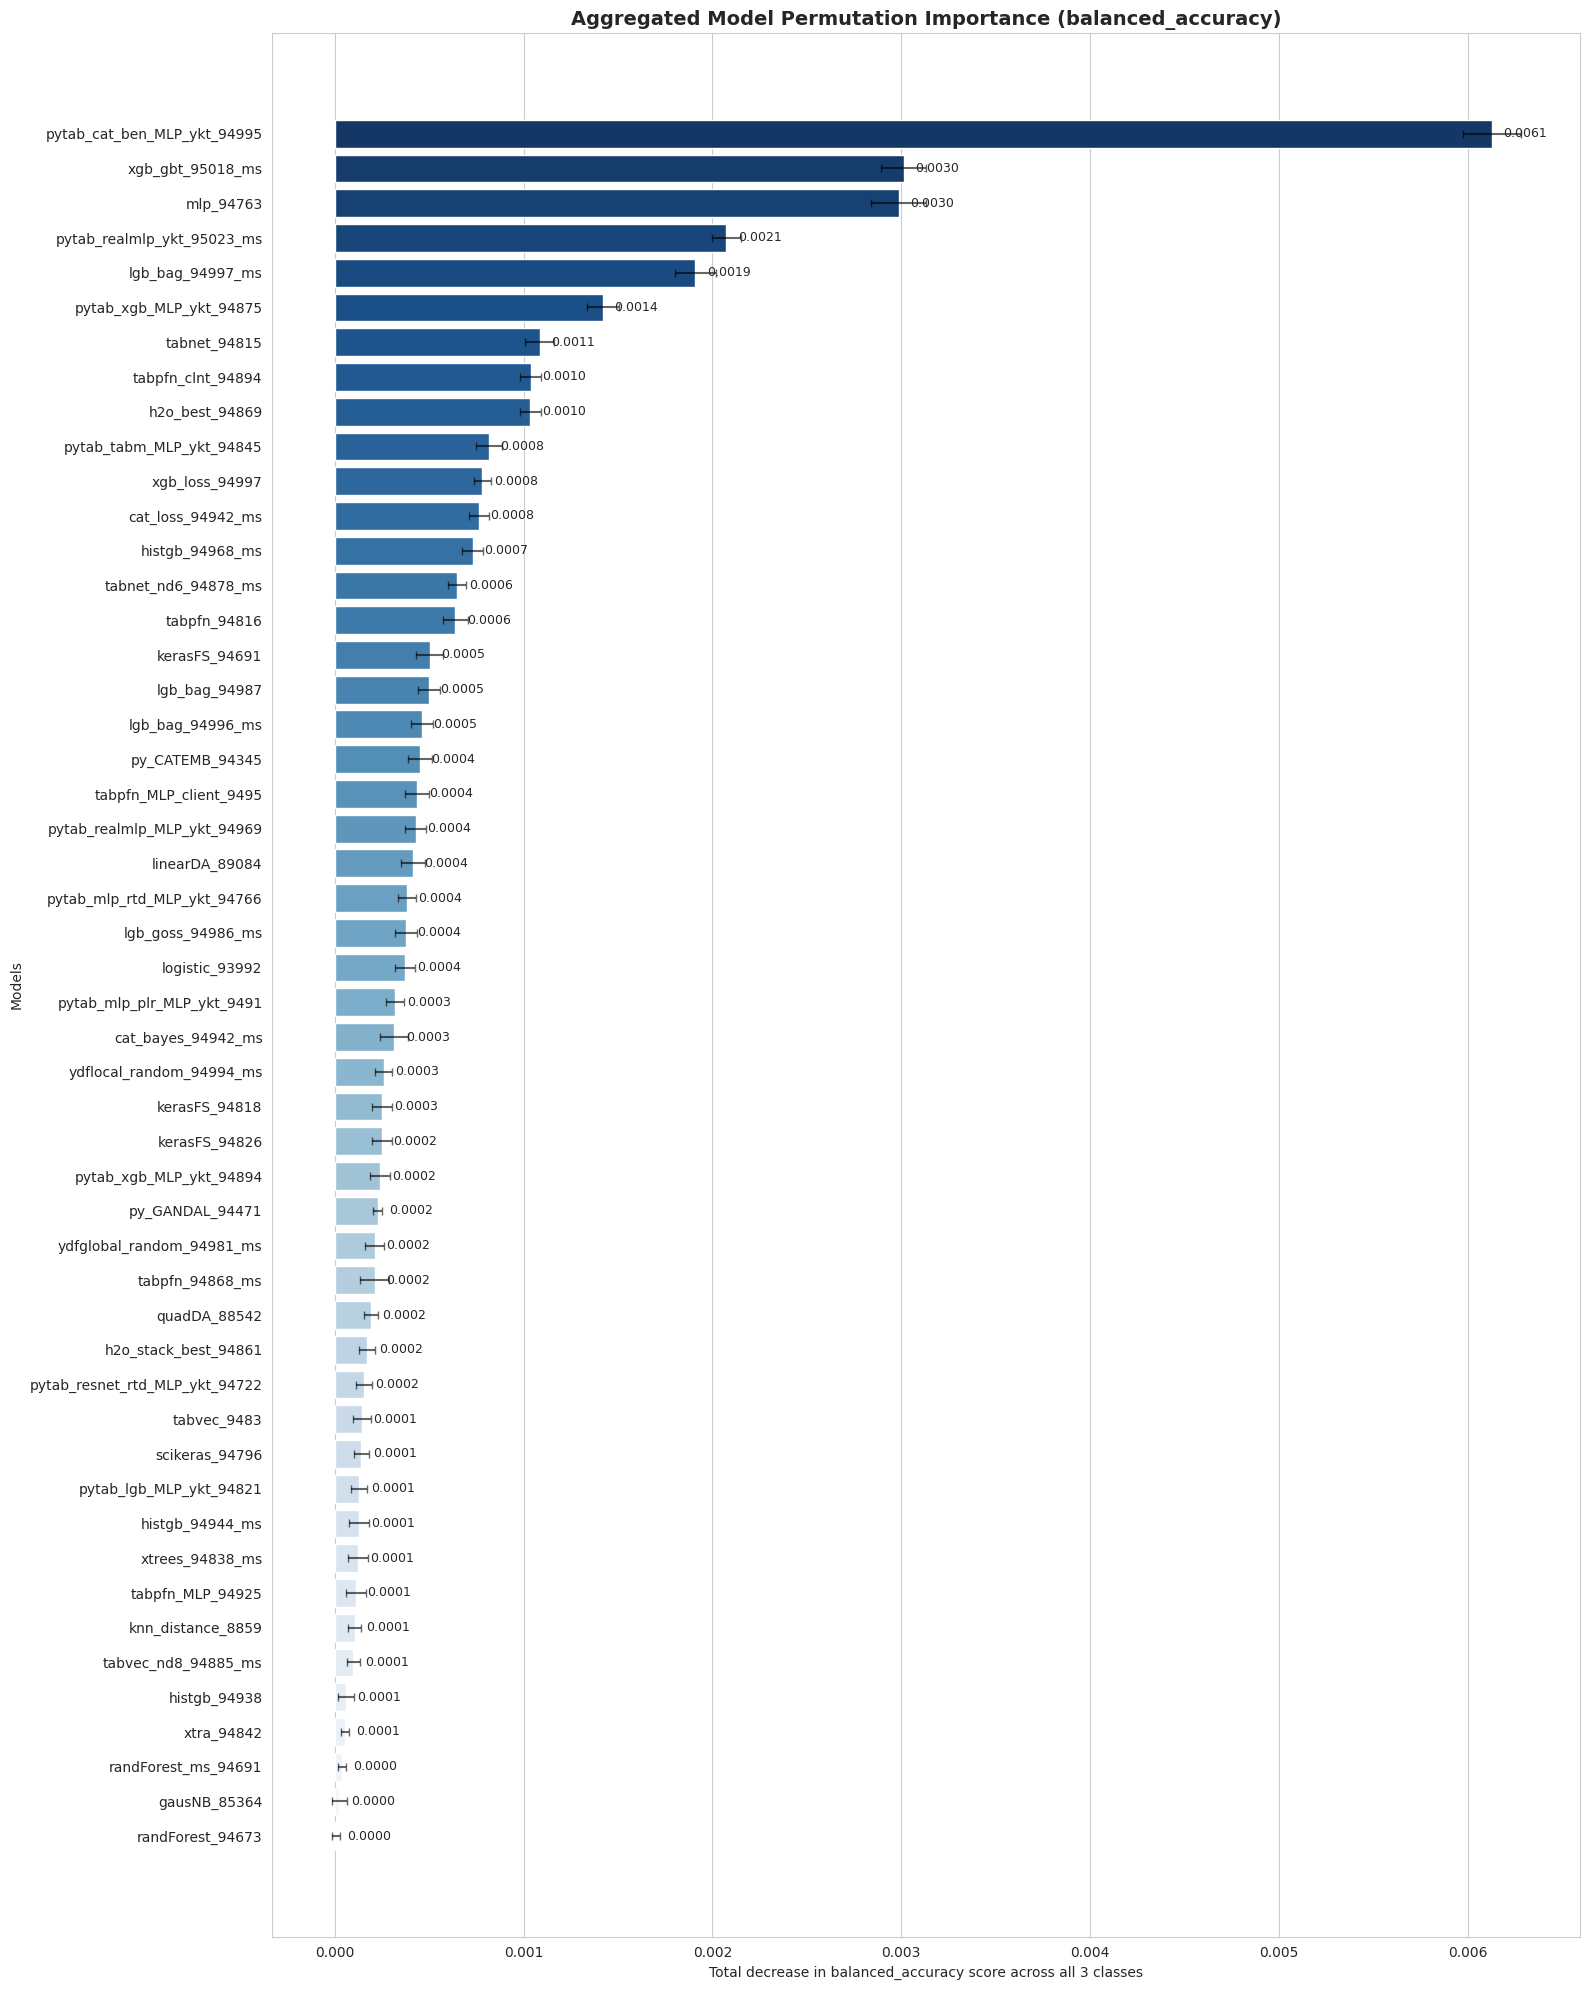

CPU times: user 8.47 s, sys: 1.73 s, total: 10.2 s
Wall time: 5min 8s


In [44]:
%%time

l_model = LogisticRegression(**{
    'max_iter': 5000,
    'class_weight': "balanced",
    'C': study.best_params['C'],
    'tol': study.best_params['tol'],
    'random_state': CFG["SEED"],
    'n_jobs': -1,
})

X = scipy_logit(oof_df)
X_train, X_test, y_train, y_test = train_test_split(X, y_true, stratify=y_true, random_state=0)

l_model.fit(X_train, y_train)

perm_imp =  plot_permutation_importance(l_model, X_test, y_test, feature_names=[*oof_df.columns],
                                        scoring=METRIC, n_repeats=10, random_state=0, top_n=50)

In [45]:
# perm_imp

In [46]:
# def train_meta(
#     model_clf, oof_df, test_df, features, y_true,
#     n_splits=CFG["FOLDS"], convert_logit="logit",
#     scoring=None, verbose=True,
# ):
#     X = oof_df[features]
#     NUM_CLASSES = len(np.unique(y_true))

#     oof_preds   = np.zeros((oof_df.shape[0], NUM_CLASSES))
#     test_preds  = np.zeros((test_df.shape[0], NUM_CLASSES))
    
#     val_scores = []
#     oof_alphas = []
    
#     skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CFG["SEED"])

#     if model_clf == "log":
#         print(f"### {n_splits} Folds | Logistic Stacking | {X.shape} ###")
#         print("="*50)
#     elif model_clf == "cat":
#         print(f"### {n_splits} Folds | Catboost Stacking | {X.shape} ###")
#         print("="*50)

#     for idx, (trn_idx, val_idx) in enumerate(skf.split(X, y_true), 1):

#         X_train, y_train = X.iloc[trn_idx], y_true[trn_idx]
#         X_valid, y_valid = X.iloc[val_idx], y_true[val_idx]

#         X_test = test_df[features].copy()

#         if model_clf == 'log':
#             model = LogisticRegressionCV(
#                 max_iter=10_000,
#                 tol=1e-4, cv=5, n_jobs=-1,
#                 multi_class='multinomial',
#                 class_weight='balanced',
#                 scoring=scoring if scoring is not None else 'neg_log_loss',
#                 random_state=CFG['SEED'],
#             )
#             if convert_logit == 'logit':
#                 eps = 1e-6
#                 for col in features:
#                     X_train[col] = scipy.special.logit(np.clip(X_train[col].to_numpy(), eps, 1-eps))
#                     X_valid[col] = scipy.special.logit(np.clip(X_valid[col].to_numpy(), eps, 1-eps))
#                     X_test[col]  = scipy.special.logit(np.clip(X_test[col].to_numpy(), eps, 1-eps))

#                     scaler = StandardScaler()
#                     X_train[col] = scaler.fit_transform(X_train[[col]], y_true)
#                     X_valid[col] = scaler.transform(X_valid[[col]])
#                     X_test[col]  = scaler.transform(X_test[[col]])
#             elif convert_logit == "rank":
#                 for col in features:
#                     X_train[col] = scipy.stats.rankdata(X_train[col].to_numpy())
#                     X_valid[col] = scipy.stats.rankdata(X_valid[col].to_numpy())
#                     X_test[col]  = scipy.stats.rankdata(X_test[col].to_numpy())

#                     scaler = StandardScaler()
#                     X_train[col] = scaler.fit_transform(X_train[[col]], y_true)
#                     X_valid[col] = scaler.transform(X_valid[[col]])
#                     X_test[col]  = scaler.transform(X_test[[col]])

#             model.fit(
#                 X_train, y_train,
#                 # sample_weight=get_sample_weights(y_train, y_train)
#             )
#             oof_preds[val_idx] = model.predict_proba(X_valid)
#             test_preds += model.predict_proba(X_test[features])
#             val_scores.append(balanced_acc(y_valid, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {idx+1}/{n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
#                 print(f"Best 'C': {model.C_[0]:.4f}")
#             oof_alphas.append(model.C_[0])
#         elif model_clf == 'cat':
#             model = cgb.CatBoostClassifier(**{
#                 "loss_function": 'MultiClass',
#                 "eval_metric": 'MultiClass',
#                 "classes_count": NUM_CLASSES,
#                 "depth": 4,
#                 # 'l2_leaf_reg': 1.0,
#                 "random_state": CFG['SEED'],
#                 "verbose": False,
#                 "allow_writing_files": False,
#                 "thread_count": -1,
#                 "task_type": 'GPU' if torch.cuda.is_available() else 'CPU',
#             })
#             model.fit(
#                 X_train, y_train,
#                 sample_weight=get_weights(y_train, y_train)
#             )
#             oof_preds[val_idx] = model.predict_proba(X_valid)
#             test_preds += model.predict_proba(X_test[features])
#             val_scores.append(balanced_acc(y_valid, oof_preds[val_idx]))
#             if verbose:
#                 print(f"Fold {idx}/{n_splits}: {val_scores[-1:][0]:.5f}")

#     test_preds /= n_splits

#     final_score = np.round(balanced_acc(y_true, oof_preds), 5)
#     print("-"*40)
#     print(f"✔ Stack score: {final_score} | Models: {len(features)}")
#     print("-"*40)

#     return test_preds, oof_preds, final_score

# print("Stacker function ready!")

In [47]:
def train_meta(
    model_clf, oof_df, test_df, features, y_true,
    n_splits=5, reg_C=0.1, reg_tol=1e-4, convert_logit=False,
    scoring=None, verbose=True,
):
    if convert_logit:
        X = scipy_logit(oof_df[features])
    else:
        X = oof_df[features].to_numpy()

    NUM_CLASSES = len(np.unique(y_true))

    oof_preds   = np.zeros((X.shape[0], NUM_CLASSES))
    test_preds  = np.zeros((test_df.shape[0], NUM_CLASSES))
    
    val_scores  = []
    oof_alphas  = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CFG["SEED"])

    if model_clf == "log":
        print(f"• {n_splits} Folds | Logistic Stacking | Models: {len(features)//NUM_CLASSES} | {X.shape}")
        print("="*60)
    elif model_clf == "cat":
        print(f"• {n_splits} Folds | Catboost Stacking | Models: {len(features)//NUM_CLASSES} | {X.shape}")
        print("="*60)

    for idx, (trn_idx, val_idx) in enumerate(skf.split(X, y_true), 1):

        X_train, y_train = X[trn_idx], y_true[trn_idx]
        X_valid, y_valid = X[val_idx], y_true[val_idx]
        X_test = test_df[features].copy()

        if model_clf == 'log':
            model = LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                C=reg_C,
                tol=reg_tol,
                random_state=CFG['SEED'],
                n_jobs=-1,
            )
            model = make_pipeline(StandardScaler(), model)
            model.fit(
                X_train, y_train,
                # sample_weight=get_sample_weights(y_train, y_train),
            )

            oof_preds[val_idx] = model.predict_proba(X_valid)
            test_preds += model.predict_proba(X_test) / n_splits
            
            val_scores.append(balanced_acc(y_valid, oof_preds[val_idx]))

            if verbose:
                print(f"Fold {idx}/{n_splits}: {val_scores[-1:][0]:.6f}")
        else:
            print(f"   ⚠️ No model to train")
            break

    # test_preds /= n_splits

    final_score = np.round(balanced_acc(y_true, oof_preds), 6)
    print("-"*40)
    print(f"✔ Stack score: {final_score} | Models: {len(features)//NUM_CLASSES}")
    print("-"*40)

    return test_preds, oof_preds, final_score

print("Stacker function ready!")

Stacker function ready!


## ENSEMBLE 1: STACKING

## LOGISTIC

In [48]:
%%time
# study.best_params['C'], study.best_params['tol']
# (0.12891164663433188, 0.00023549791078375482)

test_log, oof_log, log_score = train_meta(
    model_clf='log',
    oof_df=oof_df,
    test_df=test_df,
    features=[*oof_df.columns],
    # features=sum(gl_models, []),
    y_true=y_true,
    reg_C=study.best_params['C'],
    reg_tol=study.best_params['tol'],
    convert_logit=True,
    n_splits=CFG["FOLDS"],
)

print()
print(oof_log.shape, test_log.shape)

# • 5 Folds | Logistic Stacking | Models: 50 | (690088, 150)
# ============================================================
# Fold 1/5: 0.951128
# Fold 2/5: 0.952755
# Fold 3/5: 0.950139
# Fold 4/5: 0.950395
# Fold 5/5: 0.948895
# ----------------------------------------
# ✔ Stack score: 0.950662 | Models: 50
# ----------------------------------------

# (690088, 3) (295753, 3)
# CPU times: user 11.7 s, sys: 4.26 s, total: 16 s
# Wall time: 2min 21s

• 5 Folds | Logistic Stacking | Models: 50 | (690088, 150)
Fold 1/5: 0.951119
Fold 2/5: 0.952749
Fold 3/5: 0.950139
Fold 4/5: 0.950395
Fold 5/5: 0.948895
----------------------------------------
✔ Stack score: 0.95066 | Models: 50
----------------------------------------

(690088, 3) (295753, 3)
CPU times: user 19.4 s, sys: 5.27 s, total: 24.7 s
Wall time: 3min


In [49]:
# %%time

# test_cat, oof_cat, cat_score = train_meta(
#     model_clf="cat",
#     oof_df=oof_df,
#     test_df=test_df,
#     features= oof_df.columns,
#     y_true=y_true,
#     # convert_logit=True,
#     # n_splits=5,
# )
# print()
# print(oof_cat.shape, test_cat.shape)

In [50]:
rng = np.random.default_rng()
selected = rng.choice(per_model_output, 1, replace=False)
print(selected)
print()
# print(rng.permutation(selected))

## -- Flatten a list of lists --
flat_list = [item for sublist in selected for item in sublist]
print(rng.permutation(flat_list))

[['kerasFS_94818__c0' 'kerasFS_94818__c1' 'kerasFS_94818__c2']]

['kerasFS_94818__c0' 'kerasFS_94818__c2' 'kerasFS_94818__c1']


In [51]:
list_a = [c for c in range(len(per_model_output))][:10]
print(f"Original list: {list_a}")

pop_item = list_a.pop(int(rng.choice(list_a, 1, replace=False)[0]))
print(f"Popped item: {pop_item}")
print(f"Updated list: {list_a}")

list_a_perm = rng.permutation(list_a)
print(f"Shuffle list: {[int(a) for a in list_a_perm]}")

Original list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Popped item: 0
Updated list: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Shuffle list: [7, 5, 1, 3, 2, 8, 9, 6, 4]


In [52]:
FINAL_SCORES  = {}
FINAL_MODELS  = {}
LOOP_ROUNDS = 5

for i in tqdm(range(LOOP_ROUNDS)):
    t0 = time()
    best_score  = 0
    best_models = []

    all_models  = usable_columns.copy() # per_model_output
    models_id   = [_ for _ in range(len(all_models))]
    ## -----------------------------------------------
    shuffle_id  = rng.permutation(models_id)
    starter_id  = [int(a) for a in shuffle_id][0]
    ## -----------------------------------------------
    init_model  = all_models[starter_id]

    _id = models_id.pop(starter_id)
    other_models = [all_models[_] for _ in models_id]
    other_models = rng.permutation(other_models).tolist()

    print(f"\nLoop {i+1}/{LOOP_ROUNDS} • Starting with {init_model[0][:-3]} *****")
    
    pbar = tqdm(enumerate(other_models), total=len(other_models))

    for j, m in pbar:
        total_models = init_model + m + best_models

        print(f"\t{j+1}/{len(usable_columns)} ++ Added {m[0][:-3]} *****")
        print('-'*70)
        _, __, _score = train_meta(
            model_clf='log',
            oof_df=oof_df,
            test_df=test_df,
            y_true=y_true,
            features=total_models, 
            reg_C=study.best_params['C'],
            reg_tol=study.best_params['tol'],
            convert_logit=True,
            verbose=False,
        )

        if _score > best_score:
            print(f"{CFG['GREEN']} • {m[0][:-3]} -> improved: {_score}{CFG['RESET']}")
            best_score = _score
            best_models.extend(m)
        else:
            print(f"{CFG['RED']} • {m[0][:-3]} -> depreciate: {_score}{CFG['RESET']}")

        print()
        pbar.set_description(f"Best Score: {best_score:.6f}")

    best_models.extend(init_model)
    print(f"\nBest score: {best_score:.6f}")
    print(f"Best models: {len(best_models)//len(mapping)}\n{best_models}\n")

    FINAL_SCORES[i] = best_score
    FINAL_MODELS[i] = best_models

    print(f"{((time() - t0)/60):.2f} mins\n")

  0%|          | 0/5 [00:00<?, ?it/s]


Loop 1/5 • Starting with tabnet_94815_ *****


  0%|          | 0/49 [00:00<?, ?it/s]

	1/50 ++ Added pytab_xgb_MLP_ykt_94894_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 2 | (690088, 6)
----------------------------------------
✔ Stack score: 0.949287 | Models: 2
----------------------------------------
 • pytab_xgb_MLP_ykt_94894_ -> improved: 0.949287

	2/50 ++ Added randForest_94673_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 3 | (690088, 9)
----------------------------------------
✔ Stack score: 0.949281 | Models: 3
----------------------------------------
 • randForest_94673_ -> depreciate: 0.949281

	3/50 ++ Added pytab_resnet_rtd_MLP_ykt_94722_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 3 | (690088, 9)
----------------------------------------
✔ Stack score: 0.949455 | Models: 3
----------------------------------------
 • pytab_resnet_rtd_MLP_ykt_94

  0%|          | 0/49 [00:00<?, ?it/s]

...

	1/50 ++ Added tabpfn_MLP_94925_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 2 | (690088, 6)
----------------------------------------
✔ Stack score: 0.949636 | Models: 2
----------------------------------------
 • tabpfn_MLP_94925_ -> improved: 0.949636

	2/50 ++ Added tabnet_94815_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 3 | (690088, 9)
----------------------------------------
✔ Stack score: 0.949616 | Models: 3
----------------------------------------
 • tabnet_94815_ -> depreciate: 0.949616

	3/50 ++ Added kerasFS_94826_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 3 | (690088, 9)
----------------------------------------
✔ Stack score: 0.949929 | Models: 3
----------------------------------------
 • kerasFS_94826_ -> improved: 0.949929

	4/50 ++ Added mlp_94763_ **

  0%|          | 0/49 [00:00<?, ?it/s]

	1/50 ++ Added lgb_bag_94996_ms_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 2 | (690088, 6)
----------------------------------------
✔ Stack score: 0.949877 | Models: 2
----------------------------------------
 • lgb_bag_94996_ms_ -> improved: 0.949877

	2/50 ++ Added pytab_cat_ben_MLP_ykt_94995_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 3 | (690088, 9)
----------------------------------------
✔ Stack score: 0.950429 | Models: 3
----------------------------------------
 • pytab_cat_ben_MLP_ykt_94995_ -> improved: 0.950429

	3/50 ++ Added cat_loss_94942_ms_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 4 | (690088, 12)
----------------------------------------
✔ Stack score: 0.950422 | Models: 4
----------------------------------------
 • cat_loss_94942_ms_ -> depreciate:

  0%|          | 0/49 [00:00<?, ?it/s]

	1/50 ++ Added h2o_best_94869_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 2 | (690088, 6)
----------------------------------------
✔ Stack score: 0.949241 | Models: 2
----------------------------------------
 • h2o_best_94869_ -> improved: 0.949241

	2/50 ++ Added lgb_bag_94997_ms_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 3 | (690088, 9)
----------------------------------------
✔ Stack score: 0.94981 | Models: 3
----------------------------------------
 • lgb_bag_94997_ms_ -> improved: 0.94981

	3/50 ++ Added randForest_94673_ *****
----------------------------------------------------------------------
• 5 Folds | Logistic Stacking | Models: 4 | (690088, 12)
----------------------------------------
✔ Stack score: 0.949813 | Models: 4
----------------------------------------
 • randForest_94673_ -> improved: 0.949813

	4/50 ++ Added pytab_

In [53]:
print(FINAL_SCORES)

best_score = 0
best_id = 0
for k, v in FINAL_SCORES.items():
    if v > best_score:
        best_score = v
        best_id = k
    else:
        continue

print(f"🔥 ID: {best_id} | Score: {best_score}")# 95024

{0: np.float64(0.950754), 1: np.float64(0.950714), 2: np.float64(0.950702), 3: np.float64(0.950701), 4: np.float64(0.950663)}
🔥 ID: 0 | Score: 0.950754


In [54]:
top_models = FINAL_MODELS[best_id]
top_models

# Best score: 0.950828
# Best models: 23
# [
#     'histgb_94944_ms__c0', 'histgb_94944_ms__c1', 'histgb_94944_ms__c2',
#     'xtra_94842__c0', 'xtra_94842__c1', 'xtra_94842__c2',
#     'pytab_realmlp_MLP_ykt_94969__c0', 'pytab_realmlp_MLP_ykt_94969__c1', 'pytab_realmlp_MLP_ykt_94969__c2',
#     'py_GANDAL_94471__c0', 'py_GANDAL_94471__c1', 'py_GANDAL_94471__c2',
#     'pytab_xgb_MLP_ykt_94894__c0', 'pytab_xgb_MLP_ykt_94894__c1', 'pytab_xgb_MLP_ykt_94894__c2',
#     'tabpfn_94816__c0', 'tabpfn_94816__c1', 'tabpfn_94816__c2',
#     'randForest_ms_94691__c0', 'randForest_ms_94691__c1', 'randForest_ms_94691__c2',
#     'pytab_mlp_plr_MLP_ykt_9491__c0', 'pytab_mlp_plr_MLP_ykt_9491__c1', 'pytab_mlp_plr_MLP_ykt_9491__c2',
#     'kerasFS_94818__c0', 'kerasFS_94818__c1', 'kerasFS_94818__c2',
#     'xtrees_94838_ms__c0', 'xtrees_94838_ms__c1', 'xtrees_94838_ms__c2',
#     'pytab_cat_ben_MLP_ykt_94995__c0', 'pytab_cat_ben_MLP_ykt_94995__c1', 'pytab_cat_ben_MLP_ykt_94995__c2',
#     'mlp_94763__c0', 'mlp_94763__c1', 'mlp_94763__c2',
#     'ydflocal_random_94994_ms__c0', 'ydflocal_random_94994_ms__c1', 'ydflocal_random_94994_ms__c2',
#     'tabpfn_MLP_94925__c0', 'tabpfn_MLP_94925__c1', 'tabpfn_MLP_94925__c2',
#     'tabpfn_clnt_94894__c0', 'tabpfn_clnt_94894__c1', 'tabpfn_clnt_94894__c2',
#     'lgb_bag_94997_ms__c0', 'lgb_bag_94997_ms__c1', 'lgb_bag_94997_ms__c2',
#     'kerasFS_94826__c0', 'kerasFS_94826__c1', 'kerasFS_94826__c2',
#     'logistic_93992__c0', 'logistic_93992__c1', 'logistic_93992__c2',
#     'h2o_best_94869__c0', 'h2o_best_94869__c1', 'h2o_best_94869__c2',
#     'kerasFS_94691__c0', 'kerasFS_94691__c1', 'kerasFS_94691__c2',
#     'lgb_bag_94996_ms__c0', 'lgb_bag_94996_ms__c1', 'lgb_bag_94996_ms__c2',
#     'h2o_stack_best_94861__c0', 'h2o_stack_best_94861__c1', 'h2o_stack_best_94861__c2',
#     'pytab_resnet_rtd_MLP_ykt_94722__c0', 'pytab_resnet_rtd_MLP_ykt_94722__c1', 'pytab_resnet_rtd_MLP_ykt_94722__c2',
# ]

# 29.54 mins

['pytab_xgb_MLP_ykt_94894__c0',
 'pytab_xgb_MLP_ykt_94894__c1',
 'pytab_xgb_MLP_ykt_94894__c2',
 'pytab_resnet_rtd_MLP_ykt_94722__c0',
 'pytab_resnet_rtd_MLP_ykt_94722__c1',
 'pytab_resnet_rtd_MLP_ykt_94722__c2',
 'xgb_loss_94997__c0',
 'xgb_loss_94997__c1',
 'xgb_loss_94997__c2',
 'xtrees_94838_ms__c0',
 'xtrees_94838_ms__c1',
 'xtrees_94838_ms__c2',
 'tabpfn_94816__c0',
 'tabpfn_94816__c1',
 'tabpfn_94816__c2',
 'lgb_bag_94997_ms__c0',
 'lgb_bag_94997_ms__c1',
 'lgb_bag_94997_ms__c2',
 'ydflocal_random_94994_ms__c0',
 'ydflocal_random_94994_ms__c1',
 'ydflocal_random_94994_ms__c2',
 'pytab_cat_ben_MLP_ykt_94995__c0',
 'pytab_cat_ben_MLP_ykt_94995__c1',
 'pytab_cat_ben_MLP_ykt_94995__c2',
 'xgb_gbt_95018_ms__c0',
 'xgb_gbt_95018_ms__c1',
 'xgb_gbt_95018_ms__c2',
 'tabnet_nd6_94878_ms__c0',
 'tabnet_nd6_94878_ms__c1',
 'tabnet_nd6_94878_ms__c2',
 'linearDA_89084__c0',
 'linearDA_89084__c1',
 'linearDA_89084__c2',
 'xtra_94842__c0',
 'xtra_94842__c1',
 'xtra_94842__c2',
 'tabpfn_clnt_94

In [55]:
%%time

## -- Train with selected models --
print(f"Selected features: {len(top_models)//NUM_CLASSES}\n") # top_models

test_log, oof_log, log_score = train_meta(
    model_clf="log",
    oof_df=oof_df,
    test_df=test_df,
    features=top_models,
    y_true=y_true,
    reg_C=study.best_params['C'],
    reg_tol=study.best_params['tol'],
    convert_logit=True,
    # n_splits=5,
)

print()
print(oof_log.shape, test_log.shape)

Selected features: 23

• 5 Folds | Logistic Stacking | Models: 23 | (690088, 69)
Fold 1/5: 0.951341
Fold 2/5: 0.952633
Fold 3/5: 0.950104
Fold 4/5: 0.950508
Fold 5/5: 0.949185
----------------------------------------
✔ Stack score: 0.950754 | Models: 23
----------------------------------------

(690088, 3) (295753, 3)
CPU times: user 11.6 s, sys: 2.52 s, total: 14.1 s
Wall time: 1min 11s


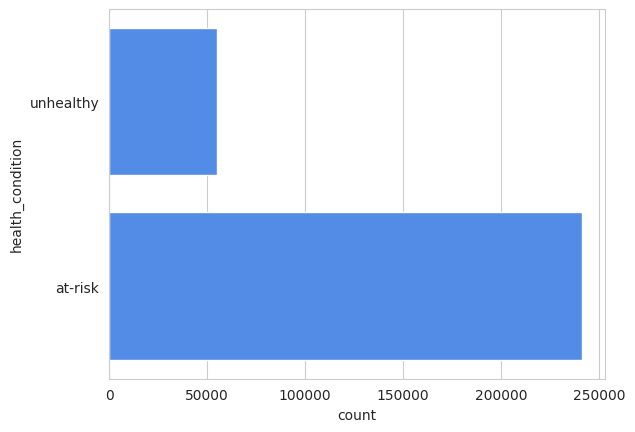

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,unhealthy
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


In [56]:
## -- Submission --
# np.save(f"oof_log_cvStack_{str(log_score).split('.')[1]}.npy", oof_log)
# np.save(f"test_log_cvStack_{str(log_score).split('.')[1]}.npy", test_log)

submit[TARGET] = pd.Series(np.argmax(test_log, axis=1)).map(r_mapping)
sns.countplot(submit[TARGET])
plt.show()

s = str(log_score).split('.')[1]
m = len(top_models) # top_models, selected
submit.to_csv(f"submit_log_cvStack{m}_{s}.csv", index=False)
submit

In [57]:
%%time

## -- Train on full data --
log_clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    C=study.best_params['C'],
    tol=study.best_params['tol'],
    n_jobs=-1,
    random_state=CFG['SEED'],
)

log_clf.fit(
    oof_df[top_models], #[top_models],
    y_true,
    # sample_weight=get_weights(y_true, y_true)
)

full_preds = log_clf.predict_proba(test_df[top_models]) # [top_models]

## -- Submission --
n = f"submit_log_stackFULL_{str(log_score).split('.')[1]}.csv"
submit[TARGET] = pd.Series(np.argmax(full_preds, axis=1)).map(r_mapping)
submit.to_csv(n, index=False)
print(f"Logistic submission file {n} saved")

submit

Logistic submission file submit_log_stackFULL_950754.csv saved
CPU times: user 1.21 s, sys: 408 ms, total: 1.61 s
Wall time: 8.11 s


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


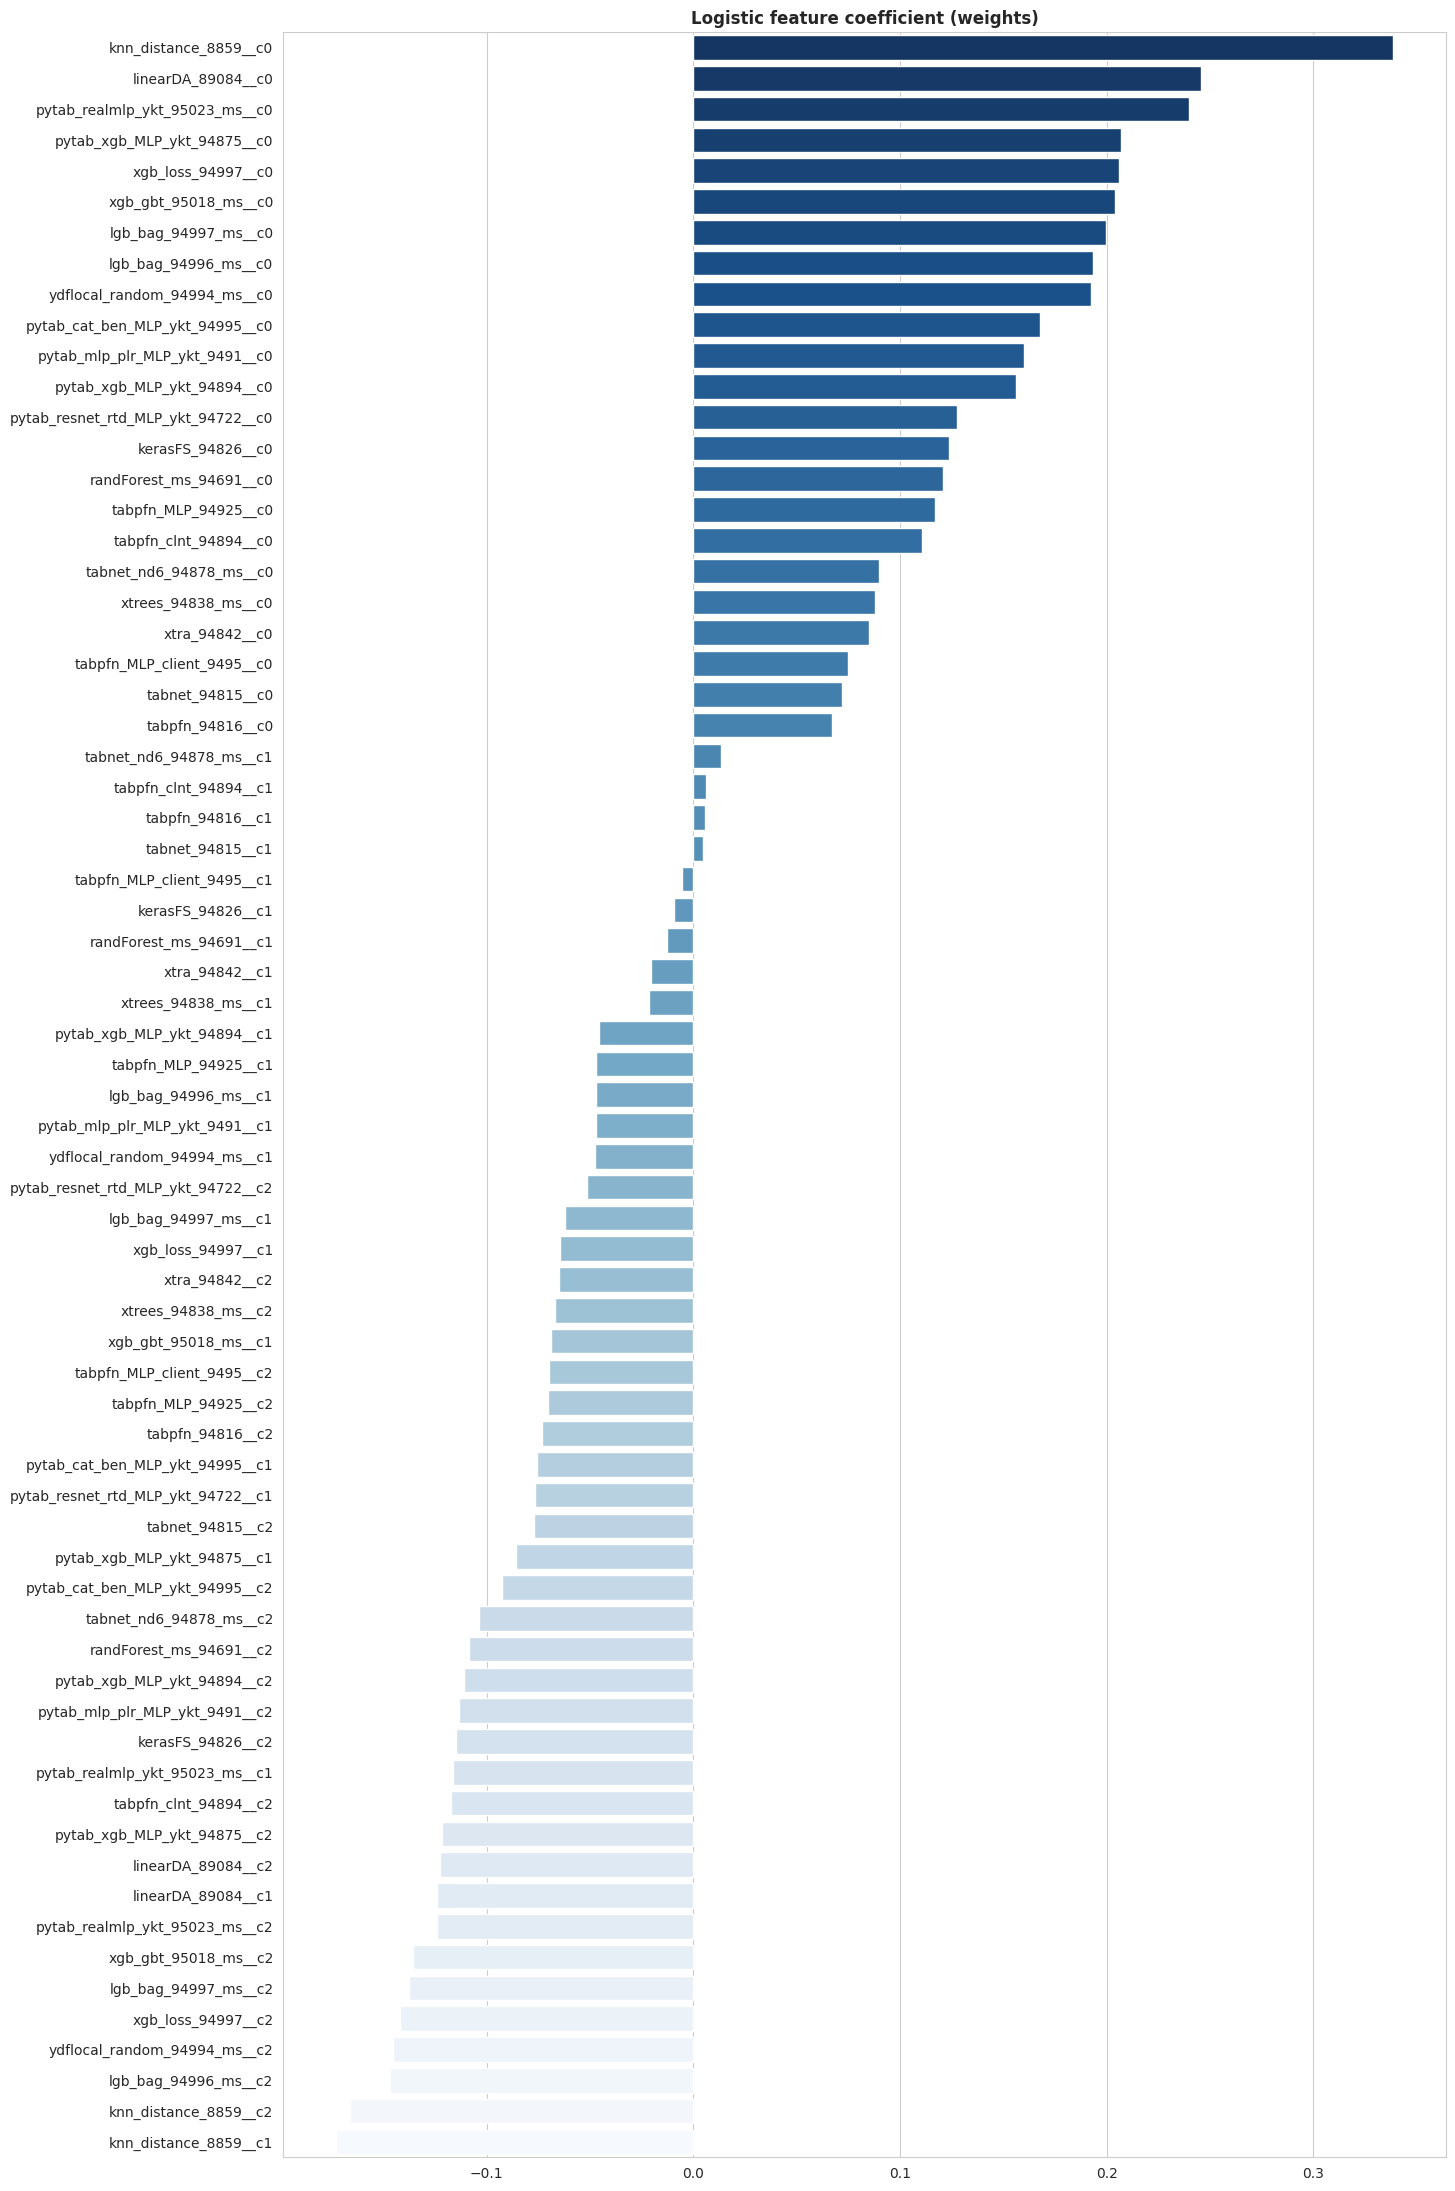

In [58]:
## -- PLOT FEATURE COEFs --
log_table = pd.Series(dict(zip(oof_df[top_models].columns, log_clf.coef_[0]))).sort_values(ascending=False)

plt.figure(figsize=(15, len(log_table)*0.4))
sns.barplot(log_table, orient="h", palette="Blues_r")
plt.title("Logistic feature coefficient (weights)", fontweight="semibold")

# plt.tight_layout()
plt.savefig('log_oof_coef')
plt.show()

In [59]:
log_features = log_table[log_table.values > 0].index.tolist()
print('Top features by Logistic:', len(log_features))

Top features by Logistic: 27


## ENSEMBLE: CLASS WEIGHT WITH OPTUNA

In [60]:
try:
    import optuna
except:
    !uv pip install -q optuna
    import optuna

def objective(trial):
    ## -- Random search class weights --
    cw0 = trial.suggest_float('cw0', 0.05, 1.0)  # Class weight 0
    cw1 = trial.suggest_float('cw1', 0.05, 1.0)  # Class weight 1
    cw2 = trial.suggest_float('cw2', 0.05, 1.0)  # Class weight 2
    
    ## Apply class weights
    class_weights = np.array([cw0, cw1, cw2])
    adjusted_probs = oof_log * class_weights
    
    ## -- Get adjusted probabilities --
    adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)
    
    ## -- Compute metric --
    bal_acc = balanced_acc(y_true, adjusted_probs)
    return bal_acc

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=123), # 123
    study_name="class_weight_optimization"
)

## -- Start Search --
study.optimize(objective, n_trials=300, show_progress_bar=True)

[I 2026-08-06 05:21:09,197] A new study created in memory with name: class_weight_optimization


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-08-06 05:21:09,292] Trial 0 finished with value: 0.9498134033962152 and parameters: {'cw0': 0.7116457263179685, 'cw1': 0.3218323682028605, 'cw2': 0.26550888088599295}. Best is trial 0 with value: 0.9498134033962152.
[I 2026-08-06 05:21:09,364] Trial 1 finished with value: 0.9499697402338946 and parameters: {'cw0': 0.5737490306287467, 'cw1': 0.7334955212962849, 'cw2': 0.45195113711823787}. Best is trial 1 with value: 0.9499697402338946.
[I 2026-08-06 05:21:09,437] Trial 2 finished with value: 0.9501765893122456 and parameters: {'cw0': 0.9817259884653847, 'cw1': 0.7005882516556201, 'cw2': 0.5068853064101428}. Best is trial 2 with value: 0.9501765893122456.
[I 2026-08-06 05:21:09,511] Trial 3 finished with value: 0.9498366753886801 and parameters: {'cw0': 0.422511642284443, 'cw1': 0.3760191153433259, 'cw2': 0.7425972220148396}. Best is trial 2 with value: 0.9501765893122456.
[I 2026-08-06 05:21:09,584] Trial 4 finished with value: 0.9470636536041996 and parameters: {'cw0': 0.46664

In [61]:
optuna.visualization.plot_param_importances(study)

In [62]:
optuna.visualization.plot_optimization_history(study)

In [63]:
best_score = np.round(study.best_value, 6)

print(f"\n{CFG['GREEN']} • Optua Best Score: {best_score}{CFG['RESET']}")
print("\nClass Weights:")
print(f"  class_0 = {study.best_params['cw0']:.8f}")
print(f"  class_1 = {study.best_params['cw1']:.8f}")
print(f"  class_2 = {study.best_params['cw2']:.8f}")

## -- Get best weight per class --
best_cw = np.array([study.best_params['cw0'], 
                    study.best_params['cw1'], 
                    study.best_params['cw2']])

## -- Apply best weights to test predictions --
final_test_probs = test_log * best_cw
final_test_probs = final_test_probs / final_test_probs.sum(axis=1, keepdims=True)

## -- Get final labels --
final_test_preds = np.argmax(final_test_probs, axis=1)

## -- Save submission file --
file_name = f"submit_optim_weights_Optuna_{str(best_score).split('.')[1]}.csv"

submit[TARGET] = pd.Series(final_test_preds).map(r_mapping)
submit.to_csv(file_name, index=False)
submit


 • Optua Best Score: 0.95077

Class Weights:
  class_0 = 0.76851500
  class_1 = 0.72450727
  class_2 = 0.74234317


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,unhealthy
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


## ENSEMBLE: CLASS WEIGHT WITH NELDER-MEAD

In [64]:
def tune_weights_scipy(oof_proba, y_true):
    def objective(w): 
        weights = np.array([1.0, w[0], w[1]])  # fix Low=1.0
        adjusted = oof_proba * weights
        return -balanced_acc(y_true, adjusted) # negative because we minimize
    
    # try multiple starting points to avoid local minima
    best_result = None
    best_score = -1.0

    starts = [
        [1.0, 1.0],
        [0.8, 1.5],
        [1.2, 2.0],
        [0.7, 3.0],
        [1.0, 5.0],
        [0.9, 2.5],
        # -------- #
        [0.05, 1.0],
        [0.1, 1.0],
        [0.3, 3.0],
        [1.0, 10.0],
    ]

    for x0 in starts:
        result = minimize(
            objective,
            x0,
            method="Nelder-Mead",
            options={"maxiter": 5000, "xatol": 1e-5, "fatol": 1e-5, 'disp': True}
        )

        if -result.fun > best_score:
            best_score = -result.fun
            best_result = result

    best_weights = np.array([1.0, best_result.x[0], best_result.x[1]])

    return best_weights, best_score

print("Class optimiaztion function ready!")

Class optimiaztion function ready!


In [65]:
base_scipy_weights, base_scipy_score = tune_weights_scipy(oof_log, y_true)

# print(f"Baseline (argmax): {baseline_score:.5f}")
# get_stack_score = [i for i in base_stack_score.values()][0]

print('-'*50, f'{CFG['YELLOW']}')
print(f"Stacking  Score:   {best_score:.6f}")
print(f"Optimized Score:   {base_scipy_score:.6f}")
print(f"Improved  Score:   {base_scipy_score - best_score:.6f}")
print(f"{CFG['RESET']}{'-'*50}")

print(f"""Best weights *****
{[*mapping.keys()][0]}: {base_scipy_weights[0]:.8f},
{[*mapping.keys()][1]}: {base_scipy_weights[1]:.8f},
{[*mapping.keys()][2]}: {base_scipy_weights[2]:.8f}
""")

## -- Apply weights to test preidctions --
oof_log_raw  = np.argmax(oof_log, axis=1)
test_log_raw = np.argmax(test_log, axis=1)

oof_optimized  = np.argmax(oof_log * base_scipy_weights, axis=1)
test_optimized = np.argmax(test_log * base_scipy_weights, axis=1)

Optimization terminated successfully.
         Current function value: -0.950779
         Iterations: 28
         Function evaluations: 70
Optimization terminated successfully.
         Current function value: -0.950766
         Iterations: 35
         Function evaluations: 81
Optimization terminated successfully.
         Current function value: -0.950614
         Iterations: 33
         Function evaluations: 82
Optimization terminated successfully.
         Current function value: -0.950762
         Iterations: 33
         Function evaluations: 79
Optimization terminated successfully.
         Current function value: -0.950596
         Iterations: 42
         Function evaluations: 97
Optimization terminated successfully.
         Current function value: -0.950664
         Iterations: 29
         Function evaluations: 75
Optimization terminated successfully.
         Current function value: -0.950764
         Iterations: 57
         Function evaluations: 126
Optimization terminated su

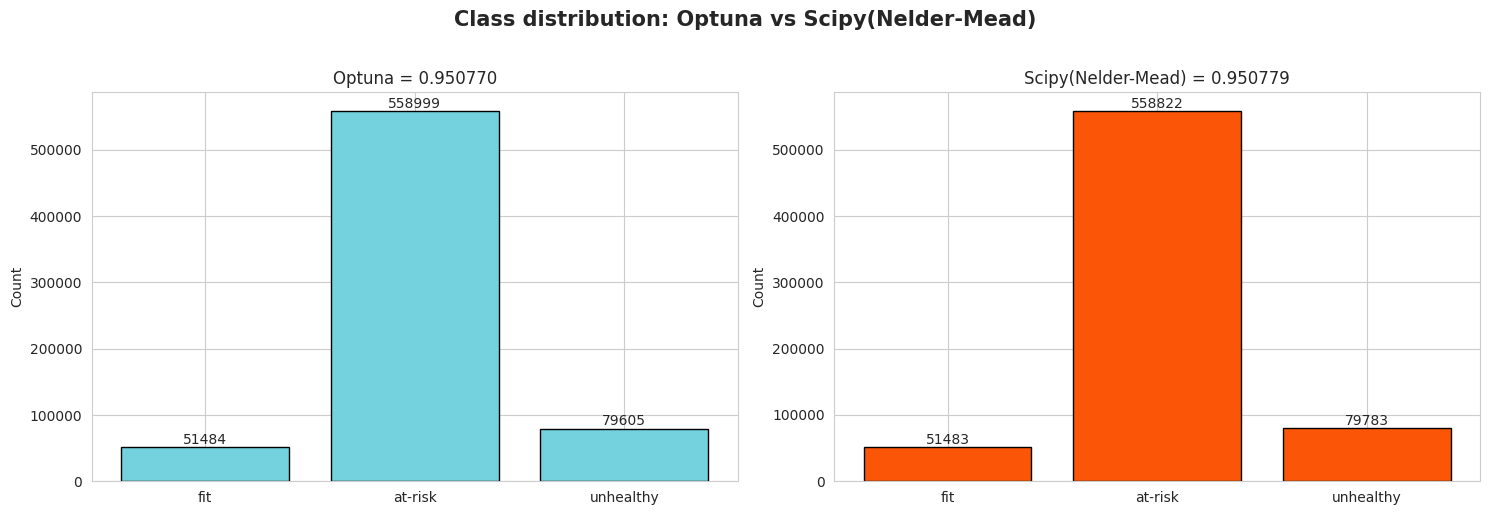

In [66]:
## -- Visualize Optuna vs Scipy --
class_names = [k for k in mapping.keys()]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, preds, title, color in [
    (axes[0], oof_log_raw, f"Optuna = {best_score:.6f}", "#73D2DE"),
    (axes[1], oof_optimized, f"Scipy(Nelder-Mead) = {base_scipy_score:.6f}", "#FB5607"),
]:
    counts = [np.sum(preds == i) for i in range(oof_log.shape[1])]
    ax.bar(class_names, counts, color=color, edgecolor="k")
    ax.set_title(title)
    ax.set_ylabel("Count")

    for i, c in enumerate(counts):
        ax.text(i, c + 5000, str(c), ha='center', fontsize=10)

plt.suptitle("Class distribution: Optuna vs Scipy(Nelder-Mead)",
             fontsize=15, y=1.02, fontweight="semibold")
plt.tight_layout()
plt.show()

In [67]:
## -- Base stack submission --
sc = f"{base_scipy_score:.6f}".split('.')[1]

# np.save(f"oof_logit_optim_{sc}.npy", oof_optimized)
# np.save(f"test_logit_optim_{sc}.npy", test_optimized)
# print("oof/test files saved as:", n_oof, n_pred)

file_name = f"submit_optim_weights_Scipy_{sc}.csv"

submit[TARGET] = pd.Series(test_optimized).map(r_mapping)
submit.to_csv(file_name, index=False)
print("Submission file saved as:", file_name)

submit

Submission file saved as: submit_optim_weights_Scipy_950779.csv


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,unhealthy
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


In [68]:
# !rm -r /kaggle/working